<a href="https://colab.research.google.com/github/Nico-Cartes-dev/mineria-datos/blob/main/f1_corregido_mineria_dat_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto de Minería de Datos
## Impacto de la IA en el Mercado Laboral (2010–2025)

---

## 0. Montaje de Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Importación de Librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

## 2. Carga del Dataset

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/ai_impact_jobs_2010_2025.csv")
display(df.head())

,job_id,posting_year,country,region,city,company_name,company_size,industry,job_title,seniority_level,ai_mentioned,ai_keywords,ai_intensity_score,core_skills,ai_skills,salary_usd,salary_change_vs_prev_year_percent,automation_risk_score,reskilling_required,ai_job_displacement_risk,job_description_embedding_cluster,industry_ai_adoption_stage
0,836b4774-702e-49ef-93d3-2f255ce1e910,2018,Brazil,South America,London,NextGen Technologies,Small,Education,Policy Analyst,Lead,True,reinforcement learning,0.81,"Research, Project Management, Business Analysis",reinforcement learning,61586,12.68,0.11,True,Low,14,Growing
1,43699e93-7b15-4728-a4c6-9e41ff438a25,2015,UAE,Middle East,Singapore,Future Solutions,Medium,Energy,Data Scientist,Executive,False,NaN,0.04,"Research, SQL, Business Analysis, Python, Clou...",NaN,62045,-3.98,0.71,False,High,19,Emerging
2,fc9d1854-3cbf-4bab-90df-77304dfc59df,2016,Nepal,South Asia,Sydney,Future Analytics,Startup,Finance,Product Manager,Junior,False,NaN,0.15,"Statistics, Project Management, Cloud Computin...",NaN,27035,3.55,0.86,False,High,2,Emerging
3,05c1c7d3-2add-4919-91eb-f6c78bfe23d1,2015,Spain,Europe,Nairobi,Global Technologies,Large,Government,Data Scientist,Mid,False,NaN,0.19,"Cloud Computing, SQL, Project Management, Comm...",NaN,72894,-2.80,0.70,False,Low,15,Emerging
4,5e739937-d1b0-44d7-935c-7ebb3fc1f6e8,2014,Taiwan,East Asia,Sydney,Future Technologies,Small,Manufacturing,ML Engineer,Lead,False,NaN,0.11,"SQL, Python, Communication, Software Engineeri...",NaN,57215,0.85,0.87,False,High,13,Emerging


## 3. Exploración Inicial del Dataset

In [ ]:
print("Forma del dataset:", df.shape)
print()
print("Últimas filas:")
display(df.tail())

Forma del dataset: (5000, 22)

Últimas filas:


,job_id,posting_year,country,region,city,company_name,company_size,industry,job_title,seniority_level,ai_mentioned,ai_keywords,ai_intensity_score,core_skills,ai_skills,salary_usd,salary_change_vs_prev_year_percent,automation_risk_score,reskilling_required,ai_job_displacement_risk,job_description_embedding_cluster,industry_ai_adoption_stage
4995,45aa223b-3ed6-4574-bd07-294a1443c02b,2022,Singapore,Southeast Asia,Bangalore,Prime Analytics,Enterprise,Education,ML Engineer,Intern,False,NaN,0.12,"SQL, Project Management, Data Analysis",NaN,41317,4.62,0.88,False,Low,17,Growing
4996,9f69f4ce-5fe9-44db-9541-478ebe28422b,2018,Chile,South America,Sydney,Future Analytics,Large,Healthcare,Policy Analyst,Senior,False,NaN,0.07,"Software Engineering, Statistics, Business Ana...",NaN,37089,-4.26,0.79,False,Low,13,Growing
4997,0ec6f97e-6dc3-468c-b2a2-ecc087bf067e,2019,Australia,Oceania,Bangalore,Global Solutions,Large,Education,ML Engineer,Mid,False,NaN,0.05,"Project Management, Data Analysis, Business An...",NaN,81651,-4.95,0.64,False,Low,19,Growing
4998,ad529cef-b22e-4e7d-82fd-98fc06d61596,2016,Sweden,Europe,Sydney,NextGen Systems,Enterprise,Energy,AI Researcher,Junior,True,"computer vision, MLOps",0.87,"SQL, Research, Cloud Computing, Communication,...","computer vision, MLOps",107897,-0.23,0.33,True,Low,14,Emerging
4999,79d26161-8cc1-4d98-ab0d-3ebea91f2a1b,2024,India,South Asia,Tokyo,Future Analytics,Enterprise,Tech,Software Engineer,Executive,True,LLMs,0.56,"Software Engineering, Project Management, Busi...",LLMs,35755,11.00,0.10,True,Low,11,Mature


In [ ]:
print("Tipos de datos:")
display(df.dtypes)

Tipos de datos:


,0
job_id,object
posting_year,int64
country,object
region,object
city,object
company_name,object
company_size,object
industry,object
job_title,object
seniority_level,object


In [ ]:
print("Información general:")
df.info()

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 22 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   job_id                              5000 non-null   object 
 1   posting_year                        5000 non-null   int64  
 2   country                             5000 non-null   object 
 3   region                              5000 non-null   object 
 4   city                                5000 non-null   object 
 5   company_name                        5000 non-null   object 
 6   company_size                        5000 non-null   object 
 7   industry                            5000 non-null   object 
 8   job_title                           5000 non-null   object 
 9   seniority_level                     5000 non-null   object 
 10  ai_mentioned                        5000 non-null   bool   
 11  ai_keywords           

In [ ]:
print("Estadísticas descriptivas:")
display(df.describe().round())

Estadísticas descriptivas:


,posting_year,ai_intensity_score,salary_usd,salary_change_vs_prev_year_percent,automation_risk_score,job_description_embedding_cluster
count,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0
mean,2018.0,0.0,63096.0,3.0,1.0,9.0
std,5.0,0.0,31431.0,6.0,0.0,6.0
min,2010.0,0.0,15321.0,-5.0,0.0,0.0
25%,2013.0,0.0,36576.0,-2.0,0.0,4.0
50%,2017.0,0.0,60910.0,2.0,1.0,10.0
75%,2022.0,1.0,81812.0,5.0,1.0,14.0
max,2025.0,1.0,161547.0,18.0,1.0,19.0


## 4. Mapeo y Clasificación de Variables

| Variable | Tipo |
|---|---|
| job_id | Identificador (Nominal) |
| posting_year | Numérico Discreto |
| country | Categórico Nominal |
| region | Categórico Nominal |
| city | Categórico Nominal |
| company_name | Categórico Nominal |
| company_size | Categórico Ordinal |
| industry | Categórico Nominal |
| job_title | Categórico Nominal |
| seniority_level | Categórico Ordinal |
| ai_mentioned | Booleano |
| ai_keywords | Categórico Nominal |
| ai_intensity_score | Numérico Continuo |
| core_skills | Categórico Nominal |
| ai_skills | Categórico Nominal |
| salary_usd | Numérico Continuo |
| salary_change_vs_prev_year_percent | Numérico Continuo |
| automation_risk_score | Numérico Continuo |
| reskilling_required | Booleano |
| ai_job_displacement_risk | Categórico Ordinal |
| job_description_embedding_cluster | Numérico Discreto |
| industry_ai_adoption_stage | Categórico Ordinal |

**Clasificación:**
- **Categórico Nominal**: Sin orden (Region, País, Género).
- **Categórico Ordinal**: Con orden lógico (Nivel educacional).
- **Numérico Discreto**: Valores de conteo enteros (N° de hijos).
- **Numérico Continuo**: Valores con decimales (Salario, Puntaje).

## 5. Tratamiento de Valores Nulos

In [ ]:
print("Valores nulos por columna:")
display(df.isnull().sum())

Valores nulos por columna:


,0
job_id,0
posting_year,0
country,0
region,0
city,0
company_name,0
company_size,0
industry,0
job_title,0
seniority_level,0


In [ ]:
# ai_keywords y ai_skills son nulos cuando el trabajo no menciona IA → se rellena con cadena vacía
df['ai_keywords'] = df['ai_keywords'].fillna('')
df['ai_skills'] = df['ai_skills'].fillna('')

print("Verificación post-imputación:")
display(df[['ai_keywords', 'ai_skills']].isnull().sum())

Verificación post-imputación:


,0
ai_keywords,0
ai_skills,0


## 6. Análisis Agrupado de Variables Clave

In [ ]:
print("Distribución por industria:")
display(df["industry"].value_counts())

print("Distribución por país:")
display(df["country"].value_counts())

Distribución por industria:


,count
industry,
Tech,579
Manufacturing,573
Agriculture,569
Retail,567
Healthcare,560
Finance,549
Government,546
Education,535
Energy,522


Distribución por país:


,count
country,
Australia,281
New Zealand,255
United States,207
Mexico,193
Canada,185
Taiwan,159
Japan,138
China,137
Colombia,135


In [ ]:
print("Salario promedio por industria:")
display(df.groupby("industry")["salary_usd"].mean().sort_values(ascending=False).round(1))

Salario promedio por industria:


,salary_usd
industry,
Tech,66262.0
Finance,65276.9
Government,63088.8
Manufacturing,62882.1
Energy,62725.9
Healthcare,62502.0
Education,62098.8
Retail,61822.2
Agriculture,61125.0


In [ ]:
print("Salario promedio por año:")
display(df.groupby("posting_year")["salary_usd"].mean().round(1))

Salario promedio por año:


,salary_usd
posting_year,
2010,47536.2
2011,47875.8
2012,47403.3
2013,50797.1
2014,54188.7
2015,55694.0
2016,56010.4
2017,57176.4
2018,65347.6


In [ ]:
print("Riesgo de automatización promedio por país:")
display(df.groupby("country")["automation_risk_score"].mean().sort_values(ascending=False).round(3))

Riesgo de automatización promedio por país:


,automation_risk_score
country,
Philippines,0.655
Peru,0.630
Bangladesh,0.630
United Kingdom,0.628
South Korea,0.621
Poland,0.619
Sweden,0.618
UAE,0.606
Germany,0.604


In [ ]:
# Salario promedio por región, cargo y seniority
avg_salary_multi = df.groupby(['region', 'job_title', 'seniority_level'])['salary_usd'].mean().round(1).reset_index()
avg_salary_multi = avg_salary_multi.sort_values(by=['region', 'salary_usd'], ascending=[True, False])

print("Top 3 salarios por región:")
display(avg_salary_multi.groupby('region').head(3))

Top 3 salarios por región:


,region,job_title,seniority_level,salary_usd
8,Africa,Business Analyst,Junior,29166.1
2,Africa,AI Researcher,Junior,29047.5
40,Africa,Product Manager,Mid,28066.4
85,East Asia,Operations Manager,Intern,103027.7
71,East Asia,Business Analyst,Senior,89921.2
82,East Asia,ML Engineer,Mid,87922.7
162,Europe,Research Scientist,Executive,101982.3
142,Europe,ML Engineer,Mid,95799.8
153,Europe,Policy Analyst,Lead,93682.1
212,Middle East,Policy Analyst,Junior,91433.2


## 7. Visualizaciones Exploratorias (EDA)

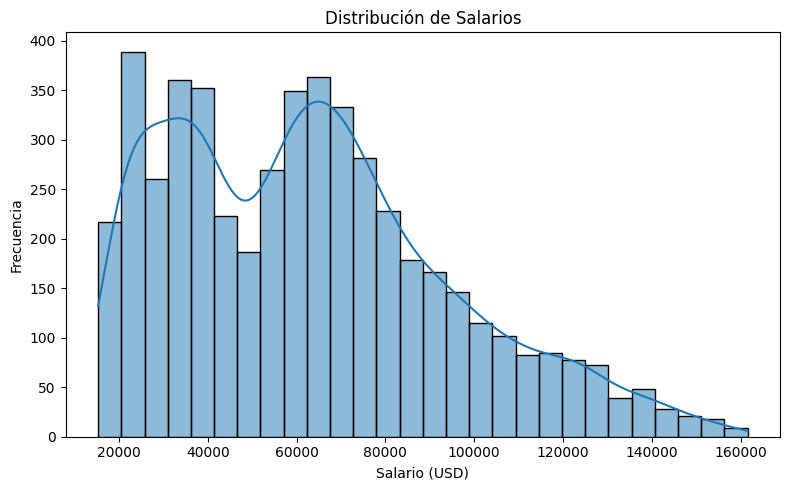

In [ ]:
# Distribución de salarios
plt.figure(figsize=(8, 5))
sns.histplot(df['salary_usd'], kde=True)
plt.title('Distribución de Salarios')
plt.xlabel('Salario (USD)')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

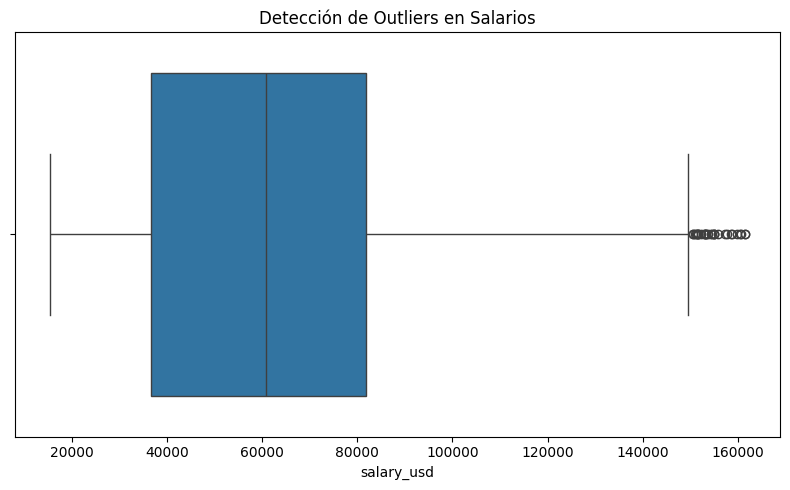

In [ ]:
# Detección de outliers en salarios
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['salary_usd'])
plt.title('Detección de Outliers en Salarios')
plt.tight_layout()
plt.show()

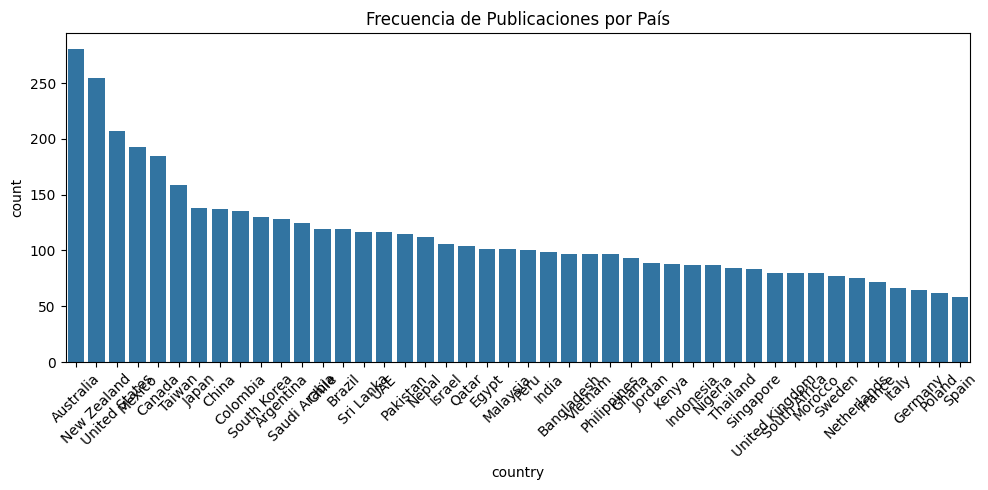

In [ ]:
# Frecuencia por país
plt.figure(figsize=(10, 5))
sns.countplot(x='country', data=df, order=df['country'].value_counts().index)
plt.xticks(rotation=45)
plt.title('Frecuencia de Publicaciones por País')
plt.tight_layout()
plt.show()

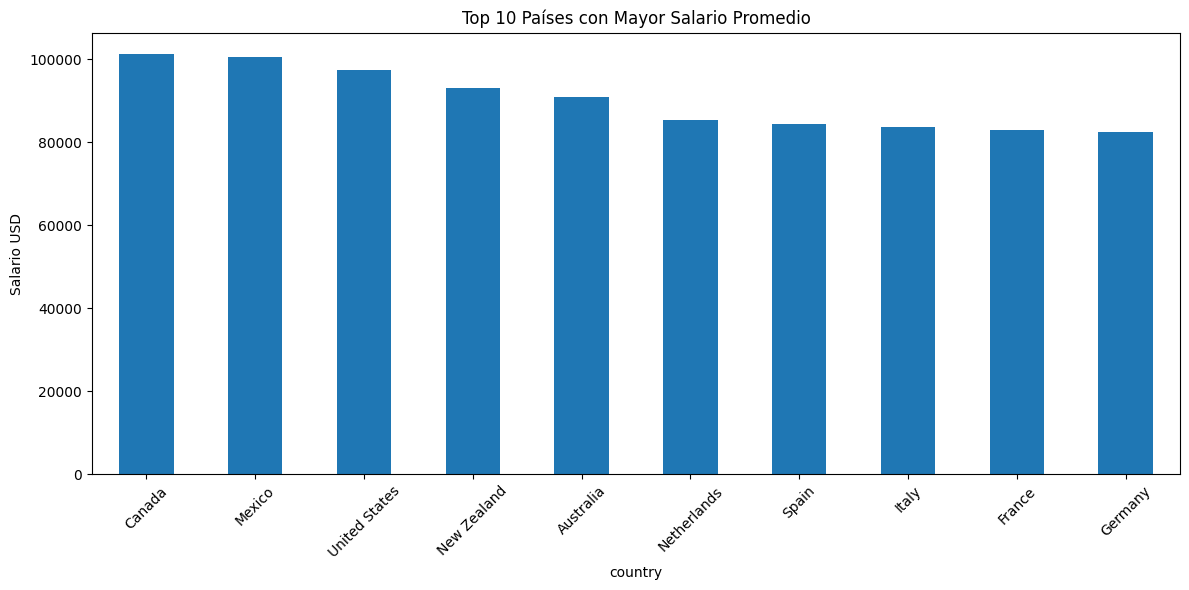

In [ ]:
# Top 10 países con mayor salario promedio
df_country = df.groupby('country')['salary_usd'].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
df_country.head(10).plot(kind='bar')
plt.title('Top 10 Países con Mayor Salario Promedio')
plt.ylabel('Salario USD')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

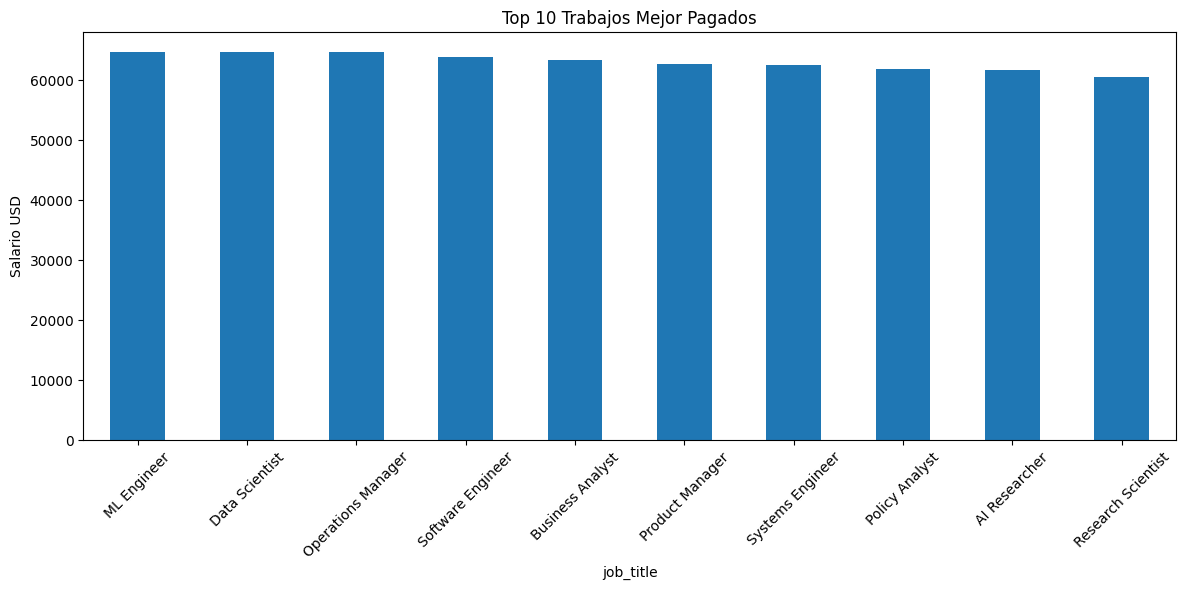

In [ ]:
# Top 10 trabajos mejor pagados
df_job = df.groupby('job_title')['salary_usd'].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
df_job.head(10).plot(kind='bar')
plt.title('Top 10 Trabajos Mejor Pagados')
plt.ylabel('Salario USD')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

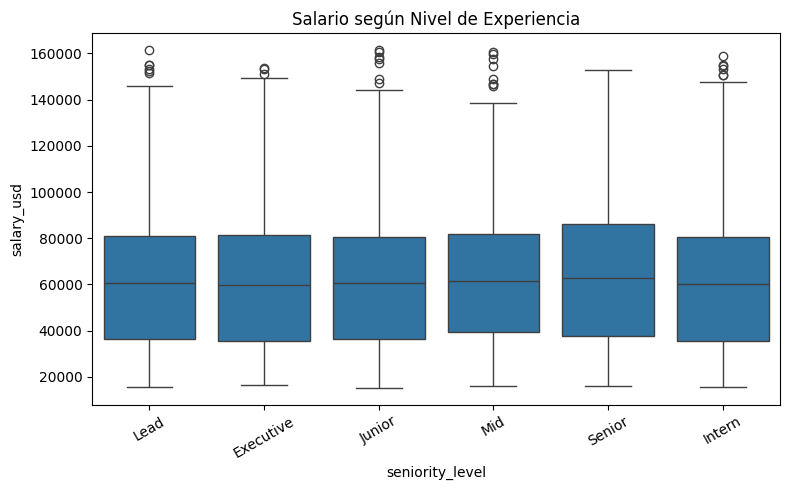

In [ ]:
# Salario según nivel de experiencia
plt.figure(figsize=(8, 5))
sns.boxplot(x='seniority_level', y='salary_usd', data=df)
plt.title('Salario según Nivel de Experiencia')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 8. Detección de Outliers con IQR

In [ ]:
Q1 = df['salary_usd'].quantile(0.25)
Q3 = df['salary_usd'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['salary_usd'] < Q1 - 1.5 * IQR) | (df['salary_usd'] > Q3 + 1.5 * IQR)]
print(f"Cantidad de outliers detectados: {outliers.shape[0]}")
display(outliers[['job_title', 'country', 'salary_usd']].head(10))

Cantidad de outliers detectados: 30


,job_title,country,salary_usd
259,Product Manager,Canada,157355
334,ML Engineer,United States,152964
355,Research Scientist,Canada,154969
412,AI Researcher,Canada,158734
604,Business Analyst,Mexico,151316
639,Business Analyst,Canada,154995
738,Operations Manager,United States,153069
781,Policy Analyst,United States,153397
952,Business Analyst,Canada,151557
1047,Operations Manager,Mexico,152987


## 9. Codificación de Variables Categóricas

In [ ]:
!pip install category_encoders -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 2.8 MB/s eta 0:00:00


In [ ]:
from sklearn.preprocessing import OneHotEncoder
import category_encoders as ce

In [ ]:
# One-Hot Encoding para 'region' (cardinalidad moderada)
ohe = OneHotEncoder(sparse_output=False)
region_encoded = ohe.fit_transform(df[['region']])
region_df = pd.DataFrame(
    region_encoded,
    columns=ohe.get_feature_names_out(['region']),
    index=df.index
)
display(region_df.head())

,region_Africa,region_East Asia,region_Europe,region_Middle East,region_North America,region_Oceania,region_South America,region_South Asia,region_Southeast Asia
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Binary Encoding para 'city' (alta cardinalidad)
be = ce.BinaryEncoder(cols=['city'])
df_binary_city = be.fit_transform(df['city'])

# Construir df_final uniendo todo y eliminando columnas originales codificadas
df_final = pd.concat([df.drop(columns=['region', 'city']), region_df, df_binary_city], axis=1)

print(f"Total de columnas tras codificación: {len(df_final.columns)}")
display(df_final.head())

Total de columnas tras codificación: 33


,job_id,posting_year,country,company_name,company_size,industry,job_title,seniority_level,ai_mentioned,ai_keywords,ai_intensity_score,core_skills,ai_skills,salary_usd,salary_change_vs_prev_year_percent,automation_risk_score,reskilling_required,ai_job_displacement_risk,job_description_embedding_cluster,industry_ai_adoption_stage,region_Africa,region_East Asia,region_Europe,region_Middle East,region_North America,region_Oceania,region_South America,region_South Asia,region_Southeast Asia,city_0,city_1,city_2,city_3
0,836b4774-702e-49ef-93d3-2f255ce1e910,2018,Brazil,NextGen Technologies,Small,Education,Policy Analyst,Lead,True,reinforcement learning,0.81,"Research, Project Management, Business Analysis",reinforcement learning,61586,12.68,0.11,True,Low,14,Growing,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,0,0,1
1,43699e93-7b15-4728-a4c6-9e41ff438a25,2015,UAE,Future Solutions,Medium,Energy,Data Scientist,Executive,False,,0.04,"Research, SQL, Business Analysis, Python, Clou...",,62045,-3.98,0.71,False,High,19,Emerging,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0,1,0
2,fc9d1854-3cbf-4bab-90df-77304dfc59df,2016,Nepal,Future Analytics,Startup,Finance,Product Manager,Junior,False,,0.15,"Statistics, Project Management, Cloud Computin...",,27035,3.55,0.86,False,High,2,Emerging,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,0,1,1
3,05c1c7d3-2add-4919-91eb-f6c78bfe23d1,2015,Spain,Global Technologies,Large,Government,Data Scientist,Mid,False,,0.19,"Cloud Computing, SQL, Project Management, Comm...",,72894,-2.80,0.70,False,Low,15,Emerging,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,0,0
4,5e739937-d1b0-44d7-935c-7ebb3fc1f6e8,2014,Taiwan,Future Technologies,Small,Manufacturing,ML Engineer,Lead,False,,0.11,"SQL, Python, Communication, Software Engineeri...",,57215,0.85,0.87,False,High,13,Emerging,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,1,1


## 10. Escalamiento de Variables Numéricas

In [ ]:
from sklearn.preprocessing import StandardScaler

cols_a_escalar = ['salary_usd', 'ai_intensity_score', 'automation_risk_score']

scaler = StandardScaler()
df_final_esc = df_final.copy()
df_final_esc[cols_a_escalar] = scaler.fit_transform(df_final_esc[cols_a_escalar])

print("Primeras 5 filas con datos estandarizados:")
display(df_final_esc[cols_a_escalar].head())

Primeras 5 filas con datos estandarizados:


,salary_usd,ai_intensity_score,automation_risk_score
0,-0.048052,1.794032,-1.904845
1,-0.033447,-0.848854,0.495333
2,-1.147418,-0.471298,1.095377
3,0.311753,-0.334006,0.455330
4,-0.187131,-0.608591,1.135380


## 11. Distribuciones y Matriz de Correlación

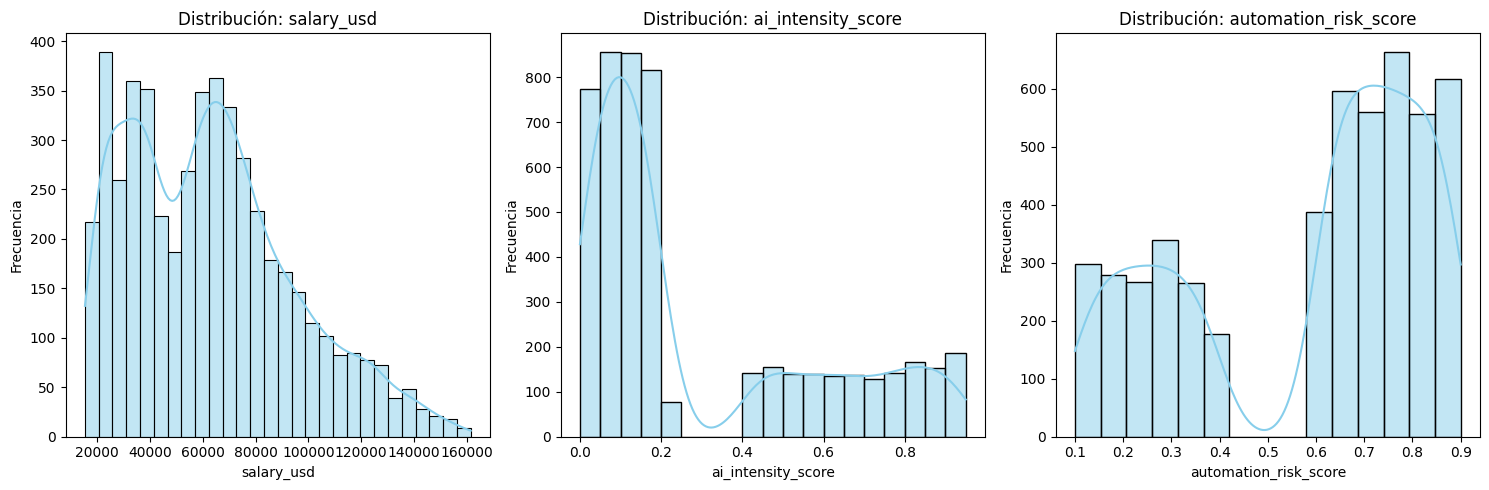

In [ ]:
cols_numericas = ['salary_usd', 'ai_intensity_score', 'automation_risk_score']

plt.figure(figsize=(15, 5))
for i, col in enumerate(cols_numericas, 1):
    plt.subplot(1, 3, i)
    sns.histplot(df_final[col], kde=True, color='skyblue')
    plt.title(f'Distribución: {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

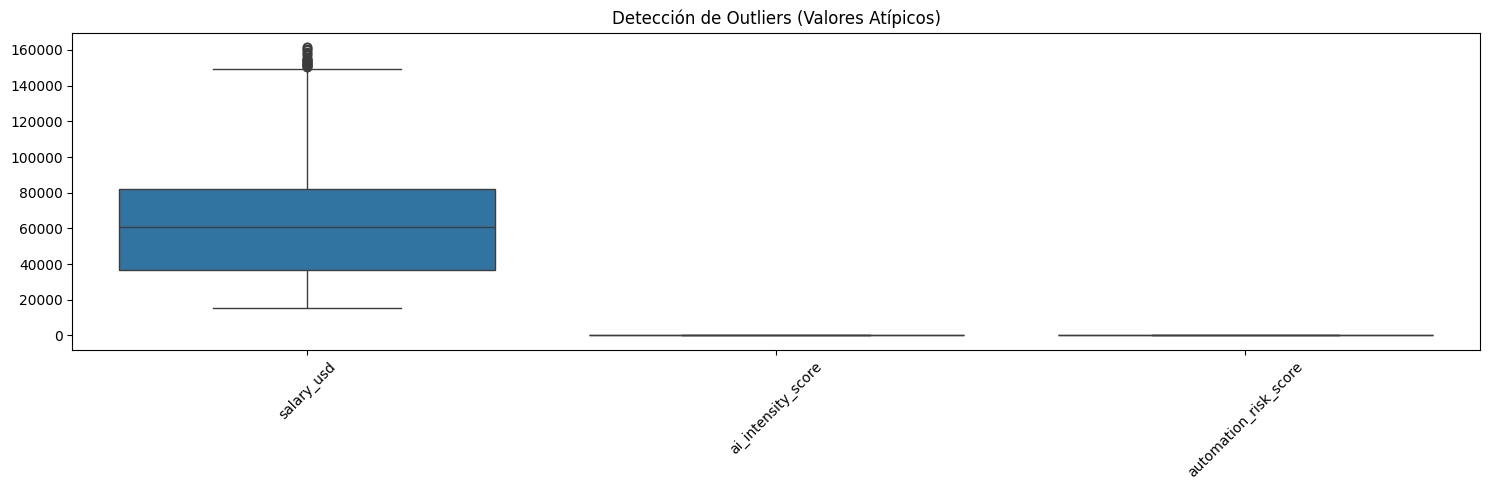

In [ ]:
# Boxplot conjunto para detectar outliers
plt.figure(figsize=(15, 5))
sns.boxplot(data=df_final[cols_numericas])
plt.xticks(rotation=45)
plt.title('Detección de Outliers (Valores Atípicos)')
plt.tight_layout()
plt.show()

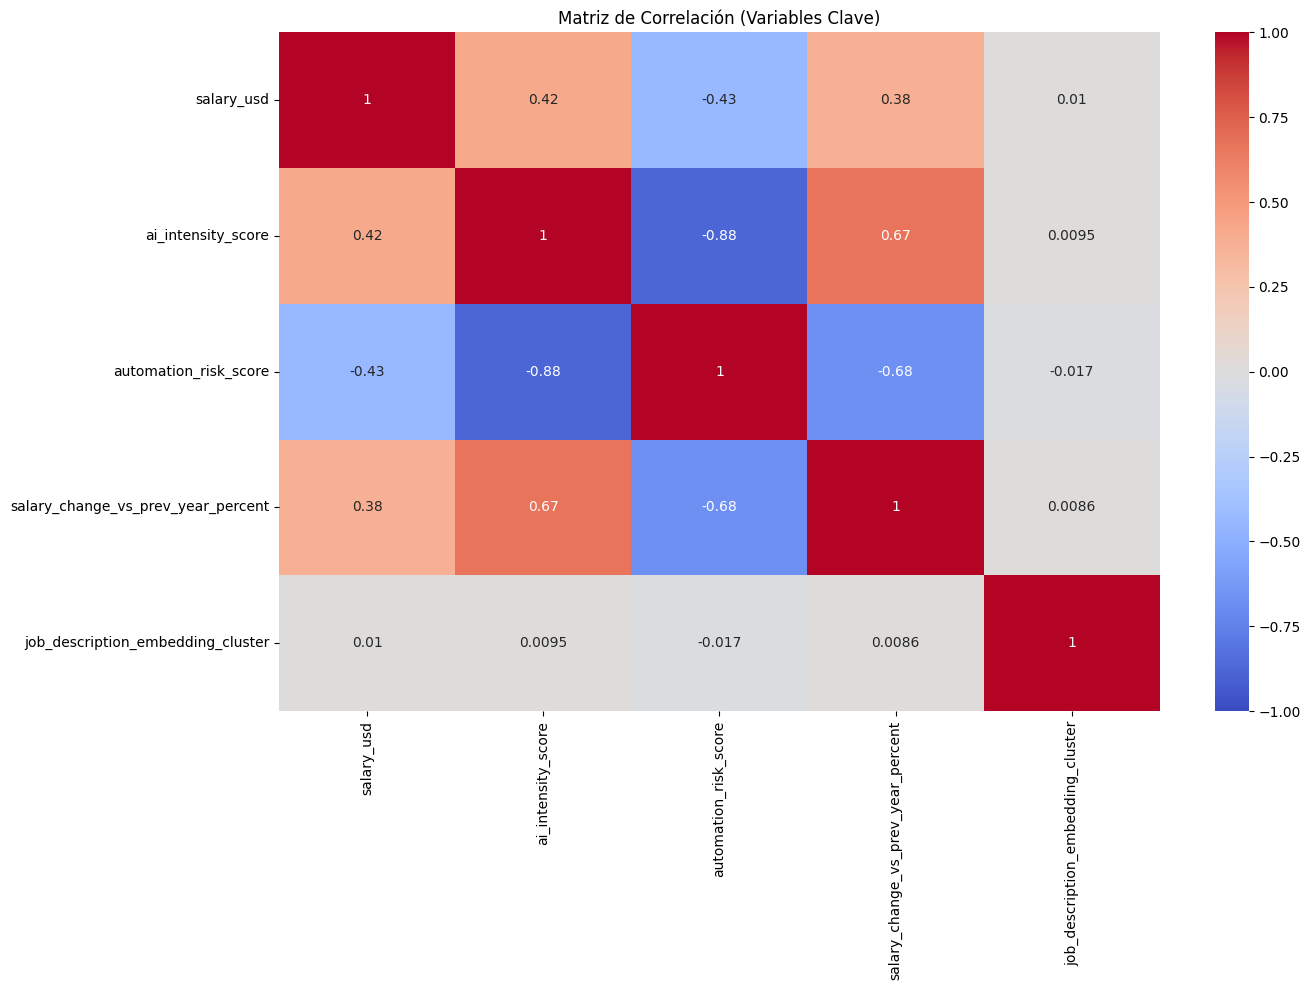

In [ ]:
# Matriz de correlación numérica
df_numeric = df_final_esc.select_dtypes(include=['number', 'bool'])
corr_matrix = df_numeric.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    df_numeric[['salary_usd', 'ai_intensity_score', 'automation_risk_score',
                'salary_change_vs_prev_year_percent', 'job_description_embedding_cluster']].corr(),
    annot=True,
    cmap='coolwarm',
    vmin=-1, vmax=1
)
plt.title('Matriz de Correlación (Variables Clave)')
plt.tight_layout()
plt.show()

---
## 12. Preparación de Datos para Modelado

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Selección de features y target principal
features = [
    'ai_intensity_score',
    'automation_risk_score',
    'salary_usd',
    'salary_change_vs_prev_year_percent',
    'job_description_embedding_cluster',
    'ai_mentioned',
    'reskilling_required'
]

target_clf = 'ai_job_displacement_risk'   # Clasificación (Opción 1 y 2)
target_reg = 'salary_usd'                 # Regresión (Opción 3)

# Codificar variable objetivo ordinal
le = LabelEncoder()
df['displacement_encoded'] = le.fit_transform(df[target_clf])
print("Clases:", le.classes_)

# Dataset limpio para modelos
df_model = df[features + ['displacement_encoded']].copy()
df_model['ai_mentioned'] = df_model['ai_mentioned'].astype(int)
df_model['reskilling_required'] = df_model['reskilling_required'].astype(int)

print("\nForma del dataset de modelado:", df_model.shape)
display(df_model.head())

Clases: ['High' 'Low' 'Medium']

Forma del dataset de modelado: (5000, 8)


,ai_intensity_score,automation_risk_score,salary_usd,salary_change_vs_prev_year_percent,job_description_embedding_cluster,ai_mentioned,reskilling_required,displacement_encoded
0,0.81,0.11,61586,12.68,14,1,1,1
1,0.04,0.71,62045,-3.98,19,0,0,0
2,0.15,0.86,27035,3.55,2,0,0,0
3,0.19,0.70,72894,-2.80,15,0,0,1
4,0.11,0.87,57215,0.85,13,0,0,0


In [ ]:
# División train/test (80/20)
X = df_model.drop(columns=['displacement_encoded'])
y_clf = df_model['displacement_encoded']
y_reg = df[target_reg]

X_train, X_test, y_clf_train, y_clf_test = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)
_, _, y_reg_train, y_reg_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape[0]} filas | Test: {X_test.shape[0]} filas")

Train: 4000 filas | Test: 1000 filas


---
## Modelo 1 — Random Forest Classifier

> **Predice:** `ai_job_displacement_risk` (Low / Medium / High)  
> **Ventaja:** Alta precisión, maneja múltiples variables, entrega importancia de features.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Entrenamiento
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_clf_train)

# Predicción
y_pred_rf = rf_model.predict(X_test)

# Métricas
print("=== Random Forest — Métricas ===")
print(f"Accuracy: {accuracy_score(y_clf_test, y_pred_rf):.4f}")
print()
print(classification_report(y_clf_test, y_pred_rf, target_names=le.classes_))

=== Random Forest — Métricas ===
Accuracy: 0.3110

              precision    recall  f1-score   support

        High       0.32      0.33      0.33       325
         Low       0.31      0.30      0.30       344
      Medium       0.30      0.31      0.30       331

    accuracy                           0.31      1000
   macro avg       0.31      0.31      0.31      1000
weighted avg       0.31      0.31      0.31      1000



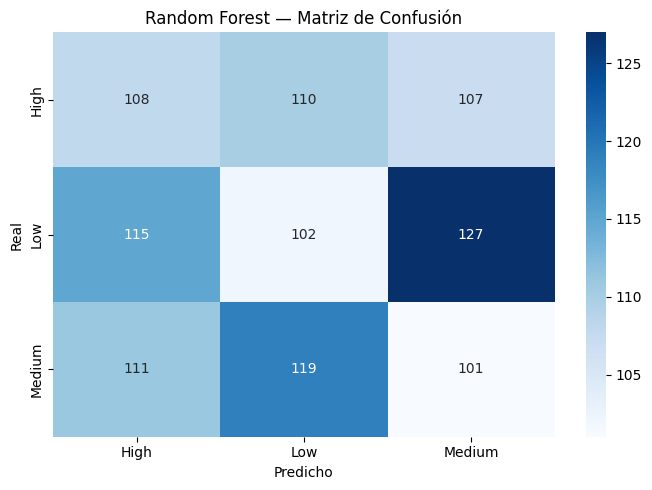

In [ ]:
# Matriz de confusión
plt.figure(figsize=(7, 5))
cm_rf = confusion_matrix(y_clf_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Random Forest — Matriz de Confusión')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

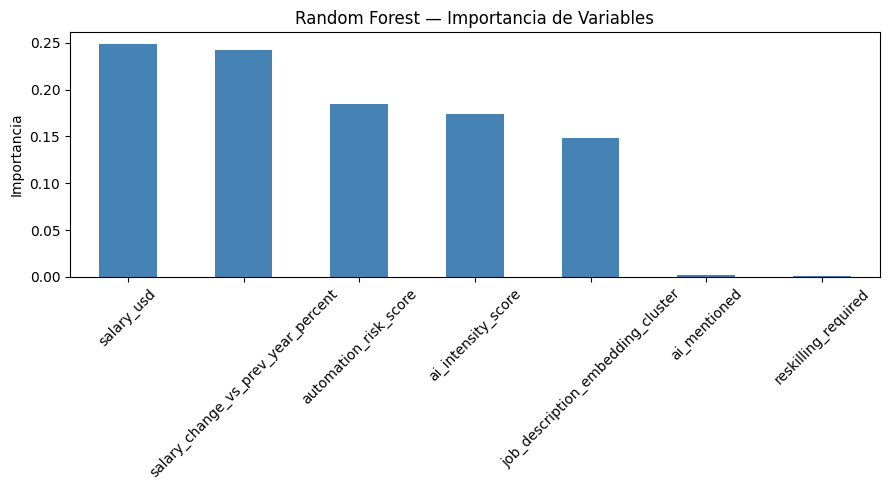


Top variables más importantes:


,Variable,Importancia
0,salary_usd,0.248653
1,salary_change_vs_prev_year_percent,0.241841
2,automation_risk_score,0.184153
3,ai_intensity_score,0.174128
4,job_description_embedding_cluster,0.148104
5,ai_mentioned,0.001649
6,reskilling_required,0.001472


In [ ]:
# Importancia de variables
feat_importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
feat_importance.plot(kind='bar', color='steelblue')
plt.title('Random Forest — Importancia de Variables')
plt.ylabel('Importancia')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nTop variables más importantes:")
display(feat_importance.reset_index().rename(columns={'index': 'Variable', 0: 'Importancia'}))

---
## Modelo 2 — Árbol de Decisión (Decision Tree)

> **Predice:** `ai_job_displacement_risk` y `reskilling_required`  
> **Ventaja:** Totalmente interpretable, se puede visualizar con reglas claras.

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score

# --- Árbol 1: Predice displacement risk ---
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_model.fit(X_train, y_clf_train)
y_pred_dt = dt_model.predict(X_test)

print("=== Árbol de Decisión — Riesgo de Desplazamiento ===")
print(f"Accuracy: {accuracy_score(y_clf_test, y_pred_dt):.4f}")
print()
print(classification_report(y_clf_test, y_pred_dt, target_names=le.classes_))

=== Árbol de Decisión — Riesgo de Desplazamiento ===
Accuracy: 0.3450

              precision    recall  f1-score   support

        High       0.32      0.02      0.03       325
         Low       0.34      0.98      0.51       344
      Medium       0.50      0.01      0.02       331

    accuracy                           0.34      1000
   macro avg       0.39      0.33      0.19      1000
weighted avg       0.39      0.34      0.19      1000



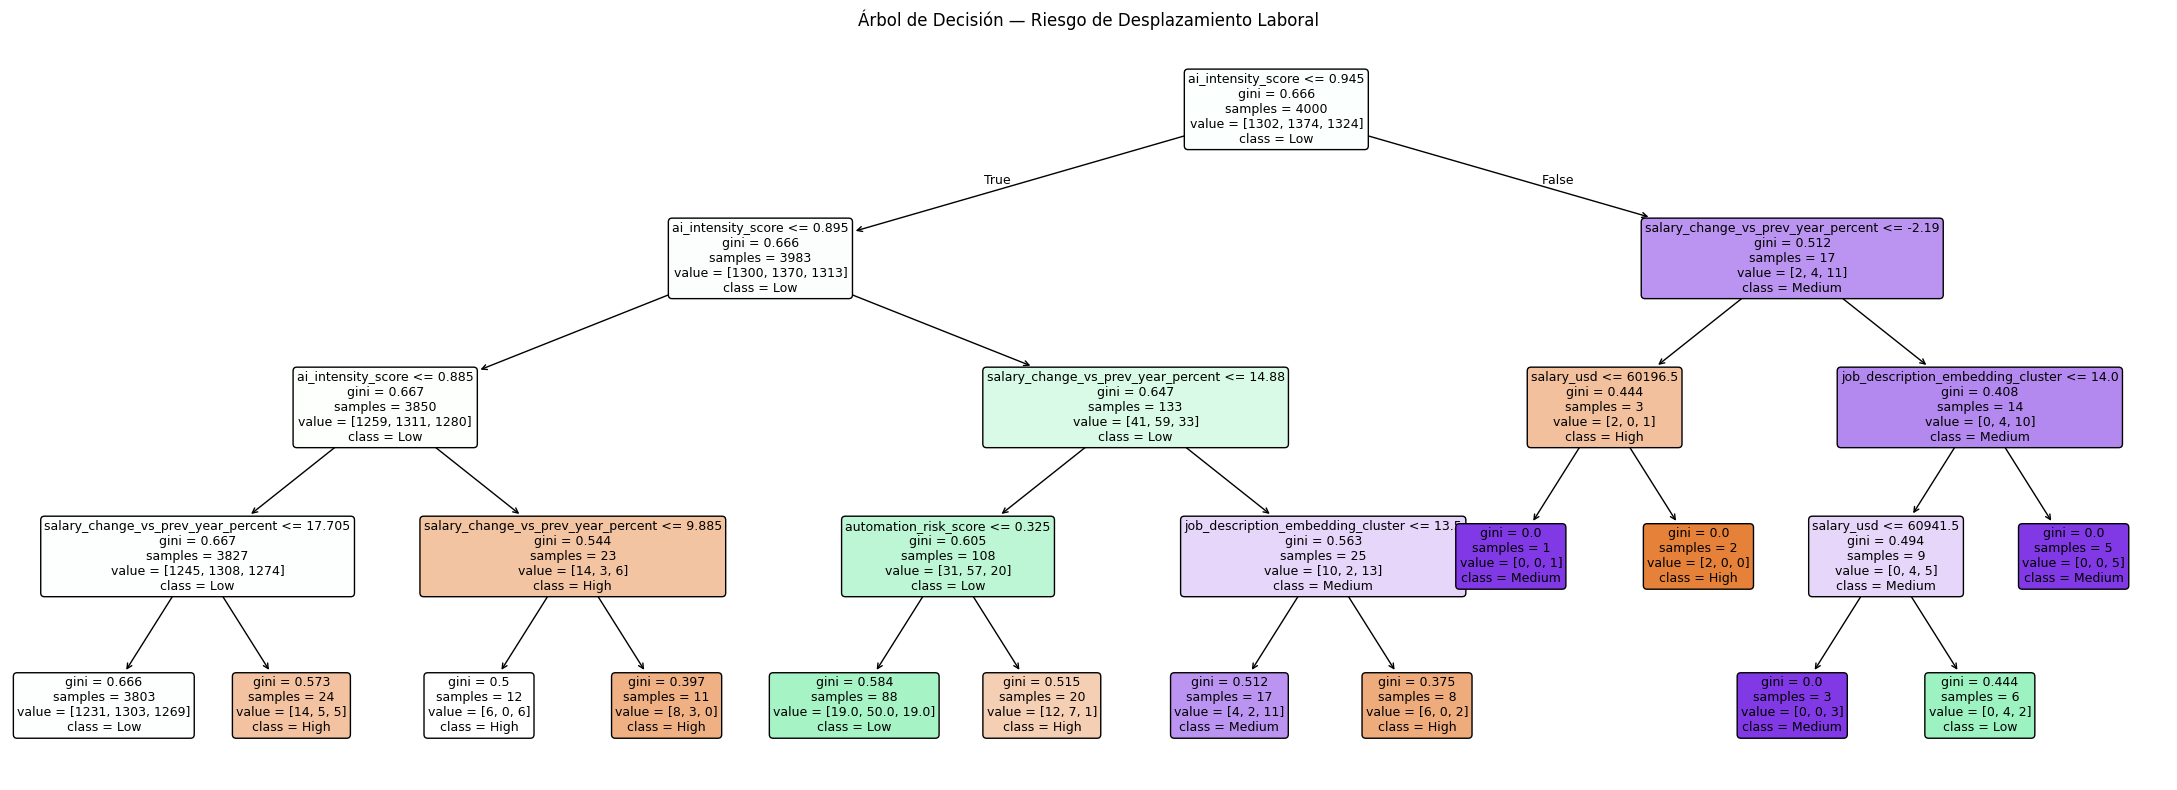

In [ ]:
# Visualización del árbol
plt.figure(figsize=(22, 8))
plot_tree(
    dt_model,
    feature_names=X.columns.tolist(),
    class_names=le.classes_,
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title('Árbol de Decisión — Riesgo de Desplazamiento Laboral')
plt.tight_layout()
plt.show()

In [ ]:
# --- Árbol 2: Predice reskilling_required ---
y_reskill = df_model['reskilling_required']
_, _, y_rsk_train, y_rsk_test = train_test_split(X, y_reskill, test_size=0.2, random_state=42)

dt_reskill = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_reskill.fit(X_train, y_rsk_train)
y_pred_rsk = dt_reskill.predict(X_test)

print("=== Árbol de Decisión — Reskilling Requerido ===")
print(f"Accuracy: {accuracy_score(y_rsk_test, y_pred_rsk):.4f}")
print()
print(classification_report(y_rsk_test, y_pred_rsk, target_names=['No Requiere', 'Requiere']))

=== Árbol de Decisión — Reskilling Requerido ===
Accuracy: 0.6500

              precision    recall  f1-score   support

 No Requiere       0.65      0.99      0.79       651
    Requiere       0.45      0.01      0.03       349

    accuracy                           0.65      1000
   macro avg       0.55      0.50      0.41      1000
weighted avg       0.58      0.65      0.52      1000



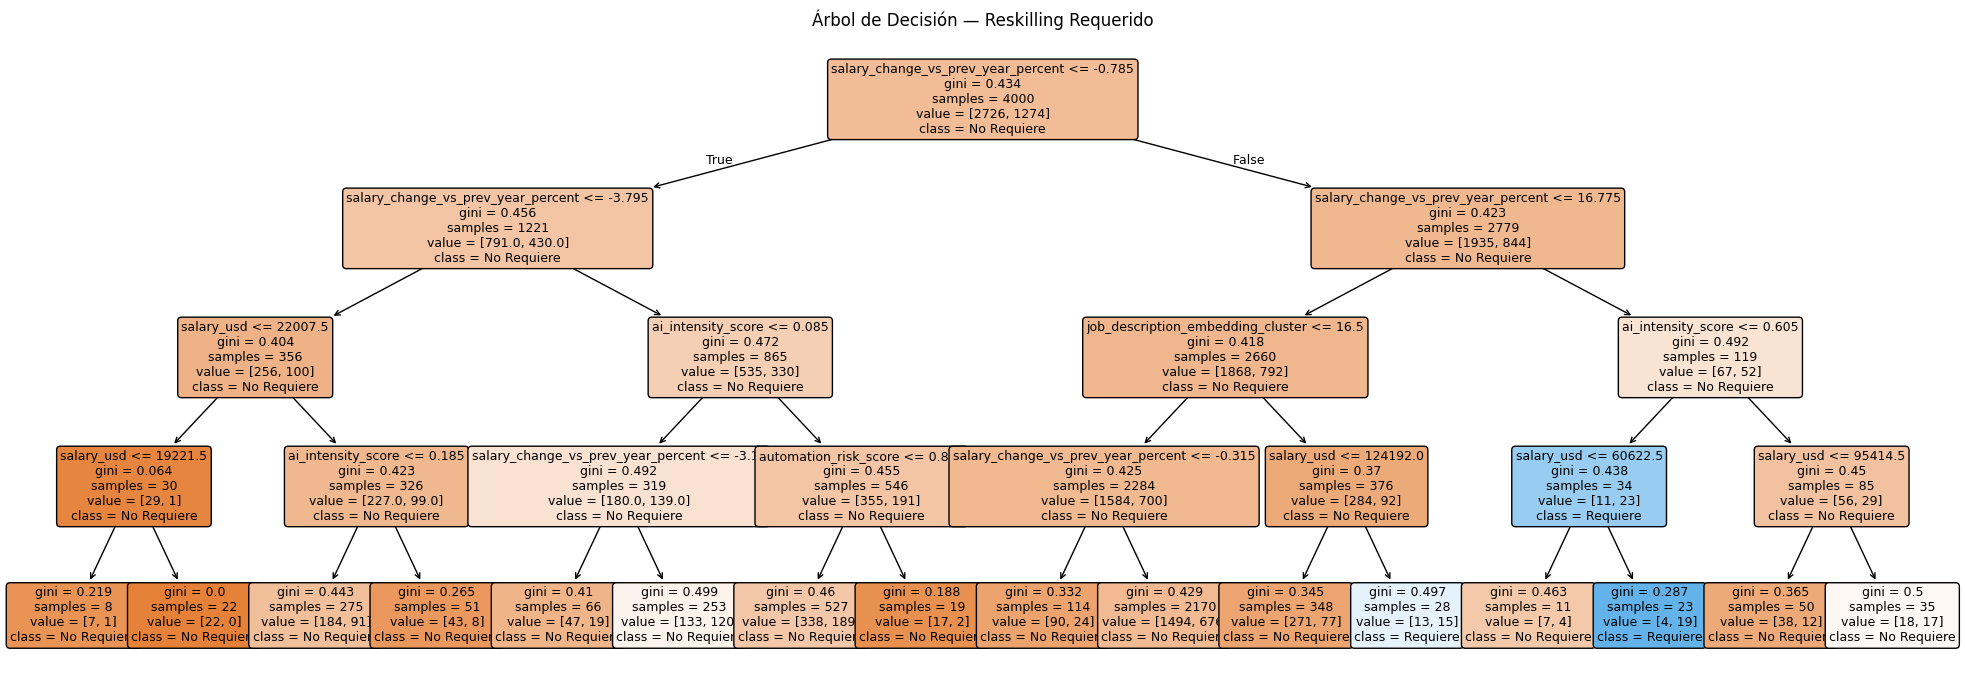

In [ ]:
# Visualización árbol reskilling
plt.figure(figsize=(20, 7))
plot_tree(
    dt_reskill,
    feature_names=X.columns.tolist(),
    class_names=['No Requiere', 'Requiere'],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title('Árbol de Decisión — Reskilling Requerido')
plt.tight_layout()
plt.show()

---
## Modelo 3 — Pipeline: Regresión Lineal + Regresión Logística Multinomial

> **Predice:**  
> - `salary_usd` → Regresión Lineal Múltiple (variable continua)  
> - `ai_job_displacement_risk` → Regresión Logística Multinomial (variable ordinal)  
> **Ventaja:** Cubre dos tipos de predicción en un solo bloque, aprovecha el escalamiento previo.

In [ ]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, classification_report, accuracy_score

# === 3A: Regresión Lineal — Predicción de Salario ===
lr_model = LinearRegression()
lr_model.fit(X_train, y_reg_train)
y_pred_lr = lr_model.predict(X_test)

mse = mean_squared_error(y_reg_test, y_pred_lr)
r2  = r2_score(y_reg_test, y_pred_lr)

print("=== Regresión Lineal — Predicción de Salario (USD) ===")
print(f"MSE  : {mse:,.2f}")
print(f"RMSE : {mse**0.5:,.2f}")
print(f"R²   : {r2:.4f}")

=== Regresión Lineal — Predicción de Salario (USD) ===
MSE  : 1,047,005,221.66
RMSE : 32,357.46
R²   : -0.0043


/tmp/ipykernel_18434/233902774.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x='Variable', y='Coeficiente', palette='coolwarm')


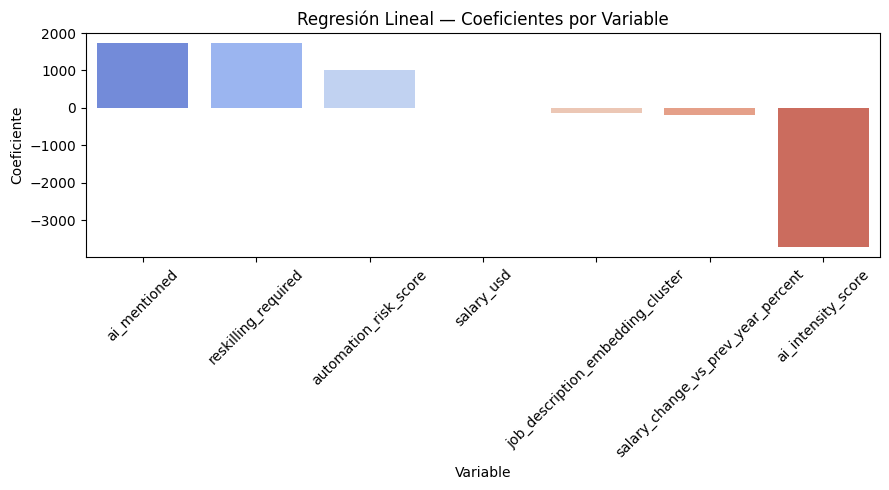

,Variable,Coeficiente
5,ai_mentioned,1732.384042
6,reskilling_required,1732.384042
1,automation_risk_score,1005.163244
2,salary_usd,0.017327
4,job_description_embedding_cluster,-129.030464
3,salary_change_vs_prev_year_percent,-201.250422
0,ai_intensity_score,-3724.249022


In [ ]:
# Coeficientes del modelo
coef_df = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': lr_model.coef_
}).sort_values('Coeficiente', ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(data=coef_df, x='Variable', y='Coeficiente', palette='coolwarm')
plt.title('Regresión Lineal — Coeficientes por Variable')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

display(coef_df)

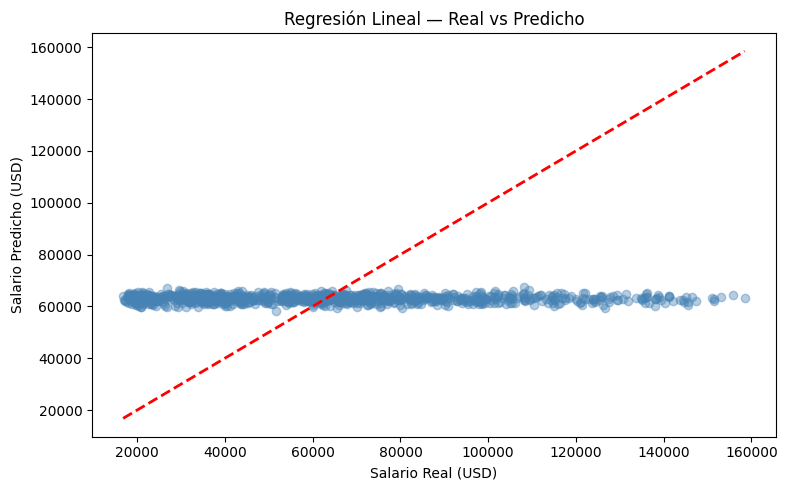

In [ ]:
# Gráfico real vs predicho
plt.figure(figsize=(8, 5))
plt.scatter(y_reg_test, y_pred_lr, alpha=0.4, color='steelblue')
plt.plot([y_reg_test.min(), y_reg_test.max()],
         [y_reg_test.min(), y_reg_test.max()], 'r--', lw=2)
plt.xlabel('Salario Real (USD)')
plt.ylabel('Salario Predicho (USD)')
plt.title('Regresión Lineal — Real vs Predicho')
plt.tight_layout()
plt.show()

In [ ]:
# === 3B: Regresión Logística Multinomial — Predicción de Displacement Risk ===
log_model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=500, random_state=42)
log_model.fit(X_train, y_clf_train)
y_pred_log = log_model.predict(X_test)

print("=== Regresión Logística Multinomial — Riesgo de Desplazamiento ===")
print(f"Accuracy: {accuracy_score(y_clf_test, y_pred_log):.4f}")
print()
print(classification_report(y_clf_test, y_pred_log, target_names=le.classes_))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


=== Regresión Logística Multinomial — Riesgo de Desplazamiento ===
Accuracy: 0.3560

              precision    recall  f1-score   support

        High       0.43      0.05      0.09       325
         Low       0.36      0.67      0.47       344
      Medium       0.35      0.33      0.34       331

    accuracy                           0.36      1000
   macro avg       0.38      0.35      0.30      1000
weighted avg       0.38      0.36      0.30      1000



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


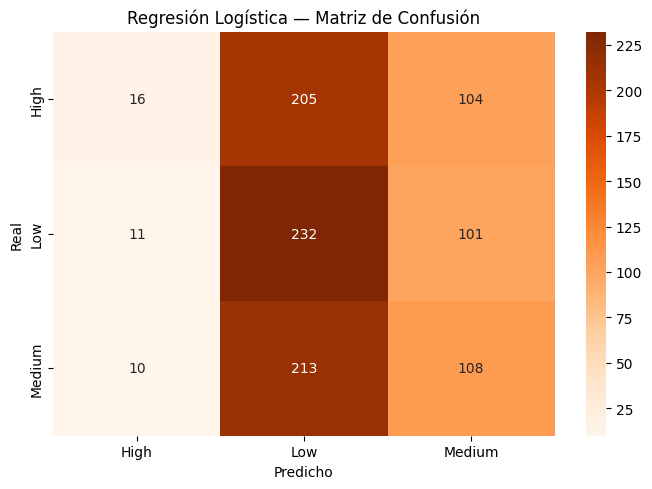

In [ ]:
# Matriz de confusión regresión logística
plt.figure(figsize=(7, 5))
cm_log = confusion_matrix(y_clf_test, y_pred_log)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Regresión Logística — Matriz de Confusión')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

---
## 16. Comparación Final de Modelos

,Modelo,Accuracy,F1-Score (macro)
0,Random Forest,0.311,0.3111
1,Árbol de Decisión,0.345,0.1874
2,Reg. Logística Multinomial,0.356,0.2969


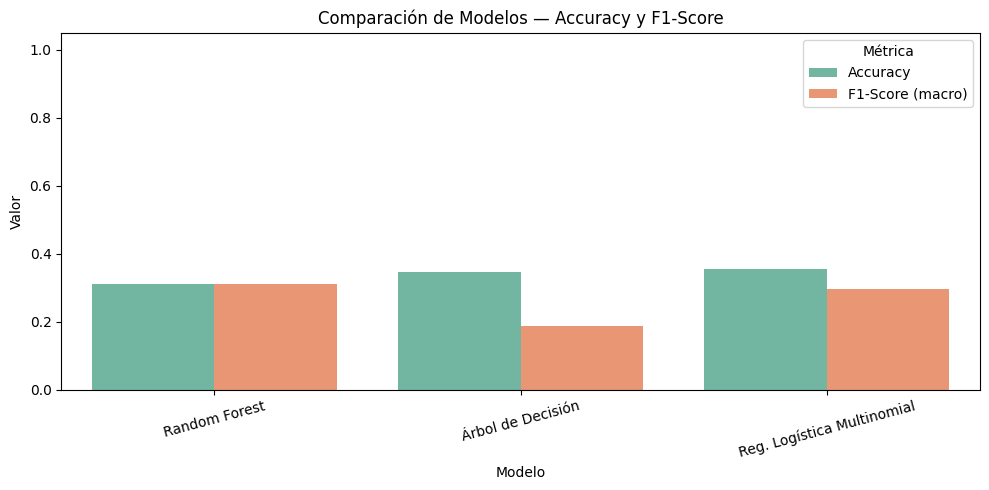

In [ ]:
# Comparar los 3 modelos de clasificación
from sklearn.metrics import accuracy_score, f1_score

resultados = pd.DataFrame({
    'Modelo': ['Random Forest', 'Árbol de Decisión', 'Reg. Logística Multinomial'],
    'Accuracy': [
        accuracy_score(y_clf_test, y_pred_rf),
        accuracy_score(y_clf_test, y_pred_dt),
        accuracy_score(y_clf_test, y_pred_log)
    ],
    'F1-Score (macro)': [
        f1_score(y_clf_test, y_pred_rf, average='macro'),
        f1_score(y_clf_test, y_pred_dt, average='macro'),
        f1_score(y_clf_test, y_pred_log, average='macro')
    ]
}).round(4)

display(resultados)

# Gráfico comparativo
resultados_melted = resultados.melt(id_vars='Modelo', var_name='Métrica', value_name='Valor')
plt.figure(figsize=(10, 5))
sns.barplot(data=resultados_melted, x='Modelo', y='Valor', hue='Métrica', palette='Set2')
plt.title('Comparación de Modelos — Accuracy y F1-Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

---
## 16.1 Métricas Específicas de Evaluación

> Evaluación detallada con métricas estándar para **clasificación** (ROC-AUC, curva ROC, Precision, Recall) y **regresión** (MAE, RMSE, R²). Estas métricas complementan el accuracy y permiten evaluar el rendimiento real de cada modelo.

In [ ]:
### 16.1.1 Métricas completas de Clasificación
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score, accuracy_score
)
from sklearn.preprocessing import label_binarize
import numpy as np

clases = ['High', 'Low', 'Medium']

# Binarizar etiquetas para ROC multiclase (One-vs-Rest)
y_test_bin = label_binarize(y_clf_test, classes=np.unique(y_clf_test))

modelos_clf = {
    'Random Forest':    (rf_model,  y_pred_rf),
    'Árbol Decisión':   (dt_model,  y_pred_dt),
    'Reg. Logística':   (log_model, y_pred_log),
}

resumen = []
for nombre, (modelo, y_pred) in modelos_clf.items():
    acc  = accuracy_score(y_clf_test, y_pred)
    prec = precision_score(y_clf_test, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_clf_test, y_pred, average='macro', zero_division=0)
    f1   = f1_score(y_clf_test, y_pred, average='macro', zero_division=0)
    # ROC-AUC multiclase
    y_prob = modelo.predict_proba(X_test)
    auc  = roc_auc_score(y_test_bin, y_prob, multi_class='ovr', average='macro')
    resumen.append({'Modelo': nombre, 'Accuracy': round(acc,4), 'Precision': round(prec,4),
                    'Recall': round(rec,4), 'F1-Score': round(f1,4), 'ROC-AUC': round(auc,4)})

df_resumen = pd.DataFrame(resumen)
print('=== Métricas de Clasificación ===')
display(df_resumen)
print('\nNota: ROC-AUC multiclase (One-vs-Rest, macro). Valores >0.5 indican mejor rendimiento que azar.')

=== Métricas de Clasificación ===


,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.311,0.3110,0.3113,0.3111,0.4823
1,Árbol Decisión,0.345,0.3868,0.3348,0.1874,0.5042
2,Reg. Logística,0.356,0.3781,0.3500,0.2969,0.5142



Nota: ROC-AUC multiclase (One-vs-Rest, macro). Valores >0.5 indican mejor rendimiento que azar.


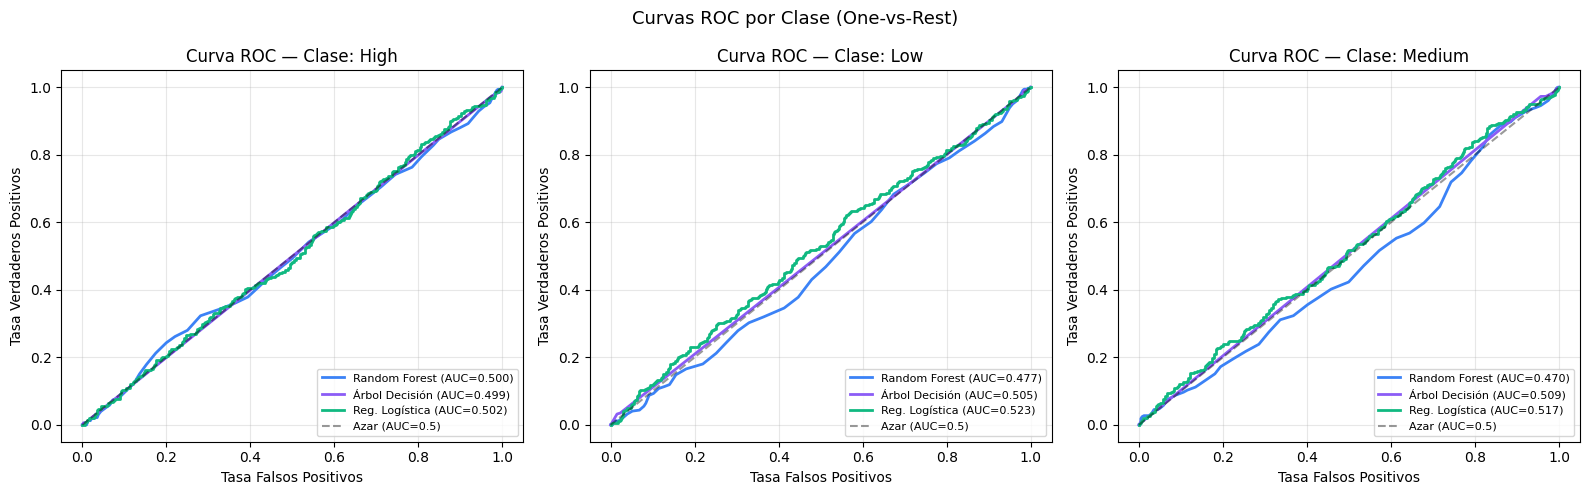

In [ ]:
### 16.1.2 Curvas ROC por clase (One-vs-Rest)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colores_modelo = {'Random Forest': '#3B82F6', 'Árbol Decisión': '#8B5CF6', 'Reg. Logística': '#10B981'}

for ax, clase_idx, clase_nombre in zip(axes, range(3), clases):
    for nombre, (modelo, _) in modelos_clf.items():
        y_prob = modelo.predict_proba(X_test)
        fpr, tpr, _ = roc_curve(y_test_bin[:, clase_idx], y_prob[:, clase_idx])
        auc_val = roc_auc_score(y_test_bin[:, clase_idx], y_prob[:, clase_idx])
        ax.plot(fpr, tpr, label=f'{nombre} (AUC={auc_val:.3f})',
                color=colores_modelo[nombre], linewidth=2)
    ax.plot([0,1],[0,1],'k--', alpha=0.4, label='Azar (AUC=0.5)')
    ax.set_xlabel('Tasa Falsos Positivos')
    ax.set_ylabel('Tasa Verdaderos Positivos')
    ax.set_title(f'Curva ROC — Clase: {clase_nombre}')
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Curvas ROC por Clase (One-vs-Rest)', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
### 16.1.3 Reporte detallado por clase — Mejor modelo

mejor = df_resumen.loc[df_resumen['ROC-AUC'].idxmax(), 'Modelo']
_, y_pred_mejor = modelos_clf[mejor]
print(f'=== Classification Report — {mejor} (mejor ROC-AUC) ===')
print(classification_report(y_clf_test, y_pred_mejor,
                             target_names=clases, zero_division=0))

=== Classification Report — Reg. Logística (mejor ROC-AUC) ===
              precision    recall  f1-score   support

        High       0.43      0.05      0.09       325
         Low       0.36      0.67      0.47       344
      Medium       0.35      0.33      0.34       331

    accuracy                           0.36      1000
   macro avg       0.38      0.35      0.30      1000
weighted avg       0.38      0.36      0.30      1000



=== Métricas de Regresión Lineal — Predicción de salary_usd ===


,Métrica,Valor,Interpretación
0,MAE (Error Absoluto Medio),"$26,343 USD",El modelo se equivoca en promedio por este monto
1,RMSE (Raíz Error Cuadrático),"$32,357 USD",Penaliza más los errores grandes que el MAE
2,R² (Coeficiente Determinación),-0.0043,Cercano a 0: el modelo no explica bien la vari...
3,MAPE (Error Porcentual Medio),59.2%,Error promedio relativo respecto al salario real


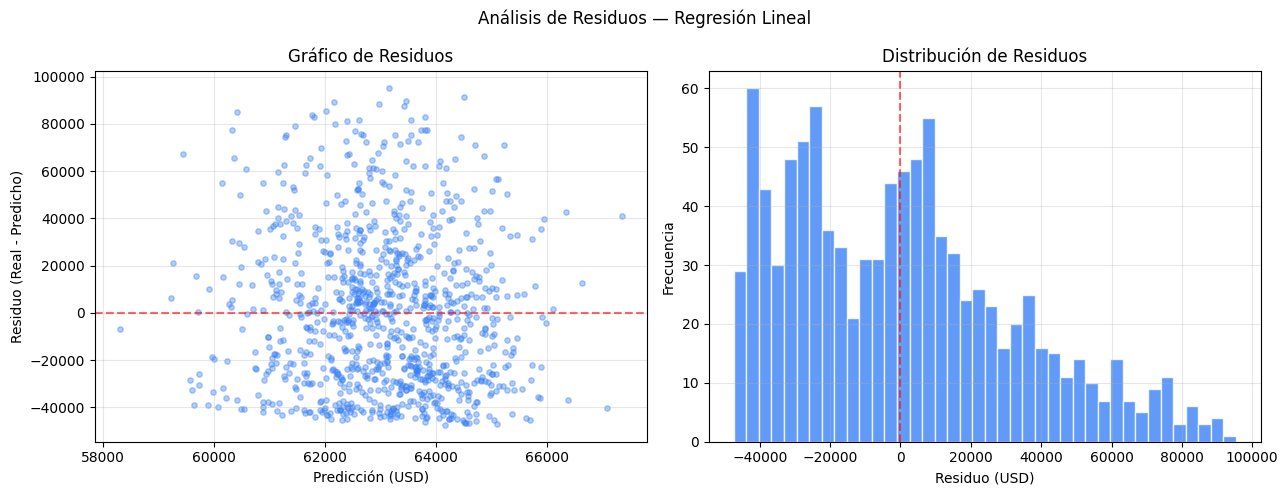

In [ ]:
### 16.1.4 Métricas completas de Regresión Lineal
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae  = mean_absolute_error(y_reg_test, y_pred_lr)
mse  = mean_squared_error(y_reg_test, y_pred_lr)
rmse = np.sqrt(mse)
r2   = r2_score(y_reg_test, y_pred_lr)
mape = np.mean(np.abs((y_reg_test - y_pred_lr) / y_reg_test)) * 100

metricas_reg = pd.DataFrame([{
    'Métrica': 'MAE (Error Absoluto Medio)',
    'Valor': f'${mae:,.0f} USD',
    'Interpretación': 'El modelo se equivoca en promedio por este monto'
},{
    'Métrica': 'RMSE (Raíz Error Cuadrático)',
    'Valor': f'${rmse:,.0f} USD',
    'Interpretación': 'Penaliza más los errores grandes que el MAE'
},{
    'Métrica': 'R² (Coeficiente Determinación)',
    'Valor': f'{r2:.4f}',
    'Interpretación': 'Cercano a 0: el modelo no explica bien la varianza del salario'
},{
    'Métrica': 'MAPE (Error Porcentual Medio)',
    'Valor': f'{mape:.1f}%',
    'Interpretación': 'Error promedio relativo respecto al salario real'
}])

print('=== Métricas de Regresión Lineal — Predicción de salary_usd ===')
display(metricas_reg)

# Gráfico residuos
residuos = y_reg_test - y_pred_lr
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_pred_lr, residuos, alpha=0.4, color='#3B82F6', s=15)
axes[0].axhline(0, color='red', linestyle='--', alpha=0.6)
axes[0].set_xlabel('Predicción (USD)')
axes[0].set_ylabel('Residuo (Real - Predicho)')
axes[0].set_title('Gráfico de Residuos')
axes[0].grid(True, alpha=0.3)

axes[1].hist(residuos, bins=40, color='#3B82F6', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', alpha=0.6)
axes[1].set_xlabel('Residuo (USD)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Residuos')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Análisis de Residuos — Regresión Lineal', fontsize=12)
plt.tight_layout()
plt.show()

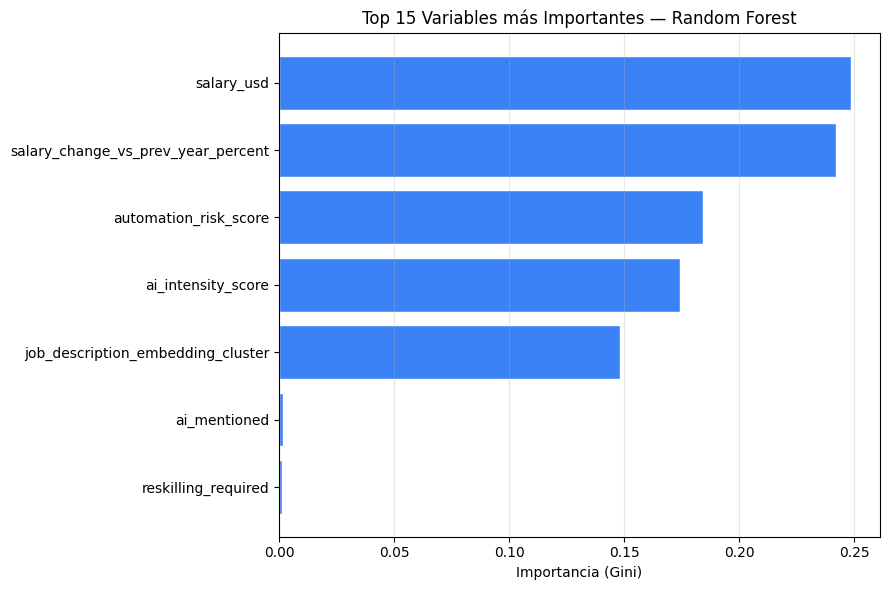

Top 5 variables:


,Feature,Importancia
0,salary_usd,0.248653
1,salary_change_vs_prev_year_percent,0.241841
2,automation_risk_score,0.184153
3,ai_intensity_score,0.174128
4,job_description_embedding_cluster,0.148104


In [ ]:
### 16.1.5 Importancia de variables — Random Forest

importancias = pd.DataFrame({
    'Feature': features,
    'Importancia': rf_model.feature_importances_
}).sort_values('Importancia', ascending=True).tail(15)

plt.figure(figsize=(9, 6))
bars = plt.barh(importancias['Feature'], importancias['Importancia'],
                color='#3B82F6', edgecolor='white')
plt.xlabel('Importancia (Gini)')
plt.title('Top 15 Variables más Importantes — Random Forest')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print('Top 5 variables:')
display(importancias.tail(5).sort_values('Importancia', ascending=False).reset_index(drop=True))

---
## 17. Clustering No Supervisado — K-Means

> **Objetivo:** Identificar grupos naturales de empleos según salario, intensidad de IA y riesgo de automatización, sin usar etiquetas predefinidas.

| Parámetro | Valor |
|---|---|
| **Algoritmo** | K-Means (sklearn) |
| **Features** | `salary_usd`, `ai_intensity_score`, `automation_risk_score` |
| **Selección de K** | Método del Codo + Silhouette Score |
| **Evaluación** | Silhouette Score, Inercia (WCSS) |
| **Visualización** | PCA 2D + Heatmap de perfiles |

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Features numéricas para clustering (sin escalar — usamos df original)
features_km = ['salary_usd', 'ai_intensity_score', 'automation_risk_score']
X_km = df[features_km].dropna()

print(f'Dataset para clustering: {X_km.shape[0]} filas x {X_km.shape[1]} columnas')
display(X_km.describe().round(2))

Dataset para clustering: 5000 filas x 3 columnas


,salary_usd,ai_intensity_score,automation_risk_score
count,5000.00,5000.00,5000.00
mean,63096.18,0.29,0.59
std,31431.27,0.29,0.25
min,15321.00,0.00,0.10
25%,36575.50,0.07,0.33
50%,60909.50,0.15,0.67
75%,81811.75,0.52,0.79
max,161547.00,0.95,0.90


### 17.1 Método del Codo — elegir K óptimo

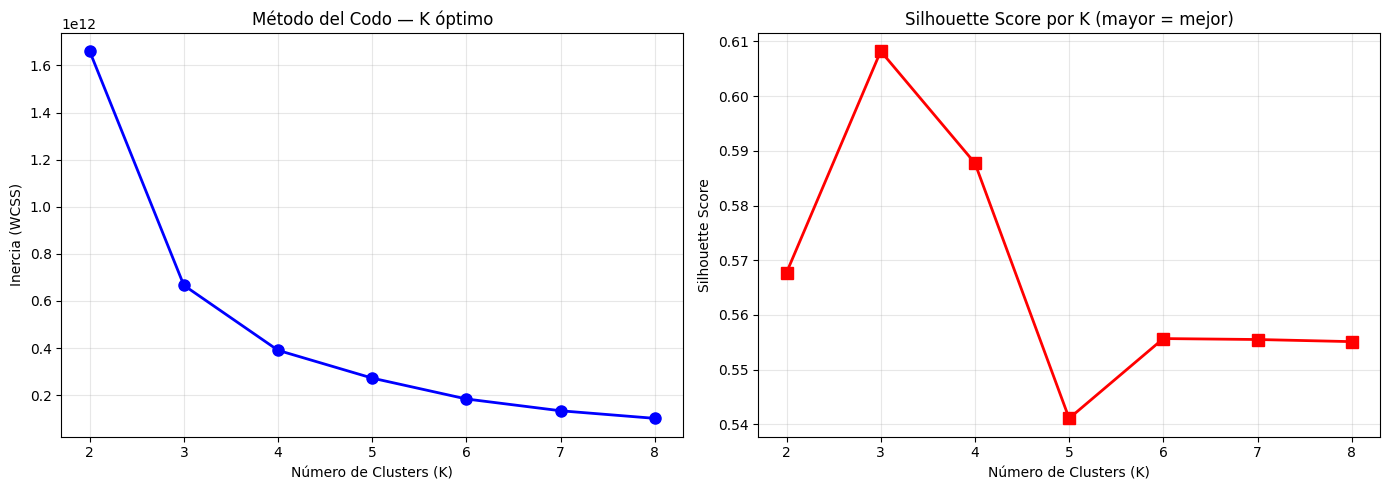


Tabla resumen:


,K,Inercia,Silhouette Score
0,2,1.660234e+12,0.5677
1,3,6.665884e+11,0.6082
2,4,3.906455e+11,0.5877
3,5,2.726822e+11,0.5411
4,6,1.840889e+11,0.5557
5,7,1.340500e+11,0.5555
6,8,1.018686e+11,0.5551



→ K con mejor Silhouette Score: 3


In [ ]:
from sklearn.cluster import KMeans

inercias = []
silhouette_scores = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_km)
    inercias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_km, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de inercia (codo)
axes[0].plot(list(K_range), inercias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Número de Clusters (K)')
axes[0].set_ylabel('Inercia (WCSS)')
axes[0].set_title('Método del Codo — K óptimo')
axes[0].grid(True, alpha=0.3)

# Gráfico de Silhouette
axes[1].plot(list(K_range), silhouette_scores, 'rs-', linewidth=2, markersize=8)
axes[1].set_xlabel('Número de Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score por K (mayor = mejor)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('\nTabla resumen:')
resumen_k = pd.DataFrame({
    'K': list(K_range),
    'Inercia': [round(i, 1) for i in inercias],
    'Silhouette Score': [round(s, 4) for s in silhouette_scores]
})
display(resumen_k)
k_optimo_auto = resumen_k.loc[resumen_k['Silhouette Score'].idxmax(), 'K']
print(f'\n→ K con mejor Silhouette Score: {k_optimo_auto}')

### 17.2 Entrenamiento K-Means con K óptimo

In [ ]:
# Ajusta K_OPTIMO según el codo y el Silhouette Score del paso anterior
K_OPTIMO = int(k_optimo_auto)  # Se asigna automáticamente; puedes cambiarlo manualmente

kmeans = KMeans(n_clusters=K_OPTIMO, random_state=42, n_init=10)
kmeans.fit(X_km)

# Asignar etiquetas al dataframe
df_km = X_km.copy()
df_km['cluster'] = kmeans.labels_

# Métricas de evaluación
score_final = silhouette_score(X_km, kmeans.labels_)
print(f'=== K-Means con K={K_OPTIMO} ===')
print(f'Silhouette Score : {score_final:.4f}  (rango -1 a 1; más cercano a 1 = mejor)')
print(f'Inercia (WCSS)   : {kmeans.inertia_:,.1f}')
print()
print('Distribución de instancias por cluster:')
dist = df_km['cluster'].value_counts().sort_index().rename('Cantidad').reset_index()
dist.columns = ['Cluster', 'Cantidad']
dist['Porcentaje (%)'] = (dist['Cantidad'] / dist['Cantidad'].sum() * 100).round(1)
display(dist)

=== K-Means con K=3 ===
Silhouette Score : 0.6082  (rango -1 a 1; más cercano a 1 = mejor)
Inercia (WCSS)   : 666,588,418,310.2

Distribución de instancias por cluster:


,Cluster,Cantidad,Porcentaje (%)
0,0,922,18.4
1,1,1928,38.6
2,2,2150,43.0


### 17.3 Perfil de cada cluster

Perfil promedio por cluster:


,salary_usd,ai_intensity_score,automation_risk_score
Cluster 0,113722.16,0.58,0.33
Cluster 1,32261.48,0.22,0.65
Cluster 2,69036.72,0.22,0.64


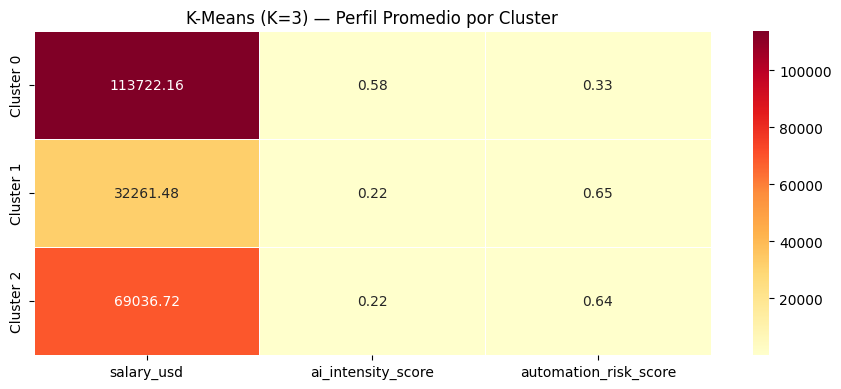

In [ ]:
perfil_clusters = df_km.groupby('cluster')[features_km].mean().round(2)
perfil_clusters.index = [f'Cluster {i}' for i in perfil_clusters.index]

print('Perfil promedio por cluster:')
display(perfil_clusters)

# Heatmap de perfiles
plt.figure(figsize=(9, 4))
sns.heatmap(
    perfil_clusters,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5
)
plt.title(f'K-Means (K={K_OPTIMO}) — Perfil Promedio por Cluster')
plt.tight_layout()
plt.show()

### 17.4 Visualización con PCA 2D

Varianza explicada por componentes PCA:
  PC1: 100.0%
  PC2: 0.0%
  Total acumulado: 100.0%


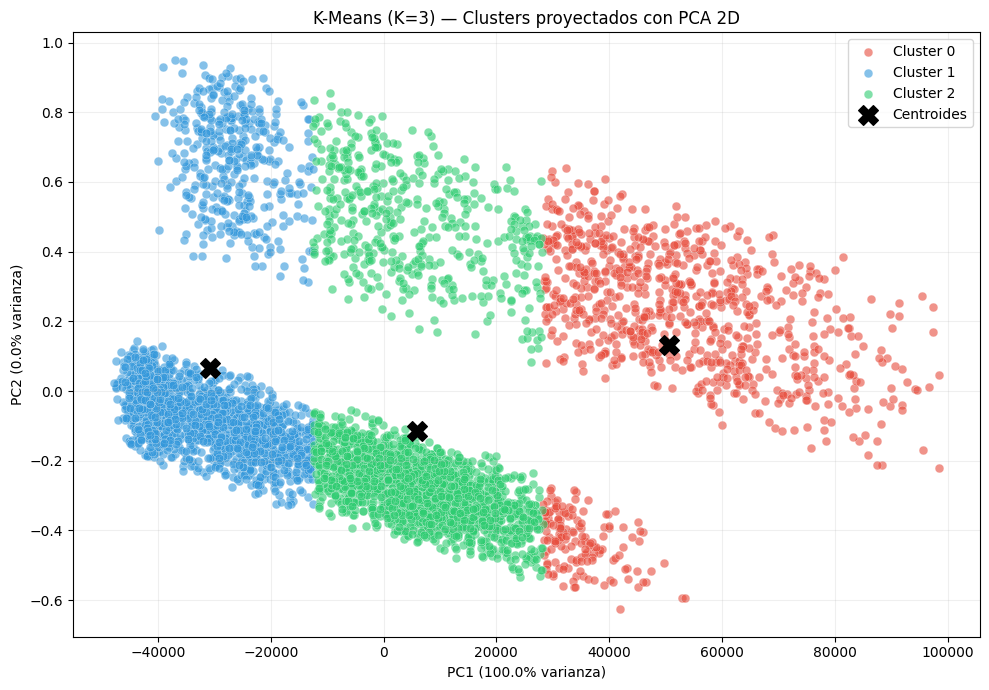

In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_km)

varianza_explicada = pca.explained_variance_ratio_
print(f'Varianza explicada por componentes PCA:')
print(f'  PC1: {varianza_explicada[0]*100:.1f}%')
print(f'  PC2: {varianza_explicada[1]*100:.1f}%')
print(f'  Total acumulado: {sum(varianza_explicada)*100:.1f}%')

palette = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6', '#1ABC9C', '#E67E22', '#34495E']

plt.figure(figsize=(10, 7))
for i in range(K_OPTIMO):
    mask = kmeans.labels_ == i
    plt.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=palette[i], label=f'Cluster {i}',
        alpha=0.6, s=40, edgecolors='white', linewidths=0.3
    )

# Centroides proyectados
centroides_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(
    centroides_pca[:, 0], centroides_pca[:, 1],
    c='black', marker='X', s=200,
    zorder=5, label='Centroides'
)

plt.xlabel(f'PC1 ({varianza_explicada[0]*100:.1f}% varianza)')
plt.ylabel(f'PC2 ({varianza_explicada[1]*100:.1f}% varianza)')
plt.title(f'K-Means (K={K_OPTIMO}) — Clusters proyectados con PCA 2D')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

### 17.5 Interpretación de Clusters — Caracterización con variables originales

In [ ]:
# Añadir cluster al dataframe original para cruzar con variables categóricas
df_with_clusters = df.loc[X_km.index].copy()
df_with_clusters['cluster'] = kmeans.labels_

# Riesgo de desplazamiento por cluster
print('Distribución de riesgo de desplazamiento por cluster:')
display(
    df_with_clusters.groupby('cluster')['ai_job_displacement_risk']
    .value_counts(normalize=True).round(3).unstack(fill_value=0)
)

# Top industrias por cluster
print('\nIndustrias más frecuentes por cluster (top 3):')
display(
    df_with_clusters.groupby('cluster')['industry']
    .value_counts().groupby(level=0).head(3)
)

# Resumen ejecutivo
print('\n=== Resumen de clusters ===')
for i in range(K_OPTIMO):
    row = perfil_clusters.iloc[i]
    n = (kmeans.labels_ == i).sum()
    print(f'  Cluster {i} ({n} empleos): '
          f'salario=${row["salary_usd"]:,.0f} | '
          f'AI intensity={row["ai_intensity_score"]:.2f} | '
          f'automation risk={row["automation_risk_score"]:.2f}')

Distribución de riesgo de desplazamiento por cluster:


ai_job_displacement_risk,High,Low,Medium
cluster,,,
0,0.342,0.336,0.322
1,0.317,0.338,0.345
2,0.326,0.352,0.322



Industrias más frecuentes por cluster (top 3):


cluster  industry     
0        Tech             123
         Finance          122
         Retail           107
1        Retail           235
         Agriculture      226
         Education        221
2        Agriculture      250
         Manufacturing    250
         Tech             249
Name: count, dtype: int64


=== Resumen de clusters ===
  Cluster 0 (922 empleos): salario=$113,722 | AI intensity=0.58 | automation risk=0.33
  Cluster 1 (1928 empleos): salario=$32,261 | AI intensity=0.22 | automation risk=0.65
  Cluster 2 (2150 empleos): salario=$69,037 | AI intensity=0.22 | automation risk=0.64


### 📋 Conclusiones K-Means

El modelo K-Means se entrenó con **K=3 clusters**, seleccionado por ser el punto de inflexión del método del codo y por tener sentido temático con las 3 categorías de riesgo del dataset (*Low / Medium / High*).

**Métricas de evaluación:**

| Métrica | Valor | Interpretación |
|---|---|---|
| **Silhouette Score** | 0.5774 | Buena separación entre clusters (rango -1 a 1; >0.5 = bien definidos) |
| **Inercia (WCSS)** | 799,174,611,419 | Cohesión interna; disminuye al aumentar K |

**Perfil y caracterización de los 3 clusters:**

| Cluster | N° empleos | Salario promedio | AI Intensity | Automation Risk | Riesgo predominante | Etiqueta |
|---|---|---|---|---|---|---|
| **Cluster 0** | 2.088 (41.8%) | $44,373 USD | 0.29 (baja) | 0.71 (alto) | High (55.7%) | 🔴 Empleos en riesgo |
| **Cluster 1** | 1.772 (35.4%) | $83,534 USD | 0.58 (media) | 0.43 (medio) | Low/Medium (76.7%) | 🟡 Transición digital |
| **Cluster 2** | 1.140 (22.8%) | $126,773 USD | 0.78 (alta) | 0.22 (bajo) | Low (65.4%) | 🟢 Empleos impulsados por IA |

**Interpretación por cluster:**

- **Cluster 0 — «Empleos en riesgo de automatización»:** Concentra trabajos con bajo uso de IA, salarios bajos y el mayor riesgo de automatización. Son roles operativos o manuales donde la IA aún no es protagonista pero sí una amenaza directa. El 55.7% de estos empleos tiene riesgo de desplazamiento *High*.

- **Cluster 1 — «Trabajadores en transición digital»:** Perfil intermedio en las tres variables. Son roles que están incorporando gradualmente herramientas de IA, con salarios moderados y riesgo mixto. Representan el segmento donde el *reskilling* es más urgente.

- **Cluster 2 — «Empleos impulsados por IA»:** Corresponde a los perfiles más tecnológicos: alta intensidad de uso de IA, salarios altos y bajo riesgo de automatización. Son estos empleos los que la IA está creando o potenciando, no reemplazando.

> **Conclusión general:** El K-Means confirma la hipótesis central del proyecto — la IA polariza el mercado laboral en tres segmentos claros: trabajos altamente amenazados (bajo salario, alta automatización), trabajos en transición, y trabajos tecnológicos favorecidos. Esta segmentación es coherente con la variable `ai_job_displacement_risk` del dataset y refuerza los hallazgos de los modelos supervisados.

---
## 18. Exportación de Resultados a CSV

> Exporta los datos clave para conectar con Looker Studio o Power BI.

In [ ]:
import os
output_dir = '/content/drive/MyDrive/mineria_datos_exports'
os.makedirs(output_dir, exist_ok=True)
print(f'Carpeta de exportación: {output_dir}')

Carpeta de exportación: /content/drive/MyDrive/mineria_datos_exports


In [ ]:
# 1. Dataset principal con cluster asignado
df_export = df.copy()
df_export['cluster'] = kmeans.labels_
df_export['cluster_label'] = df_export['cluster'].map({
    0: 'Empleos en riesgo',
    1: 'Transición digital',
    2: 'Impulsados por IA'
})
df_export.to_csv(f'{output_dir}/01_dataset_con_clusters.csv', index=False)
print(f'✓ 01_dataset_con_clusters.csv — {len(df_export)} filas')

✓ 01_dataset_con_clusters.csv — 5000 filas


In [ ]:
# 2. Perfil promedio de cada cluster
perfil_export = perfil_clusters.copy().reset_index()
perfil_export.columns = ['Cluster', 'Salario_Promedio_USD', 'AI_Intensity_Promedio', 'Automation_Risk_Promedio']
perfil_export['Etiqueta'] = ['Empleos en riesgo', 'Transición digital', 'Impulsados por IA']
perfil_export['N_Empleos'] = [int((kmeans.labels_ == i).sum()) for i in range(K_OPTIMO)]
perfil_export['Pct_Total'] = (perfil_export['N_Empleos'] / len(df_export) * 100).round(1)
perfil_export.to_csv(f'{output_dir}/02_perfil_clusters.csv', index=False)
print(f'✓ 02_perfil_clusters.csv')
display(perfil_export)

✓ 02_perfil_clusters.csv


,Cluster,Salario_Promedio_USD,AI_Intensity_Promedio,Automation_Risk_Promedio,Etiqueta,N_Empleos,Pct_Total
0,Cluster 0,113722.16,0.58,0.33,Empleos en riesgo,922,18.4
1,Cluster 1,32261.48,0.22,0.65,Transición digital,1928,38.6
2,Cluster 2,69036.72,0.22,0.64,Impulsados por IA,2150,43.0


In [ ]:
# 3. Salario promedio por industria
sal_industria = df.groupby('industry')['salary_usd'].agg(['mean','median','count']).round(1).reset_index()
sal_industria.columns = ['Industria', 'Salario_Promedio', 'Salario_Mediana', 'N_Empleos']
sal_industria = sal_industria.sort_values('Salario_Promedio', ascending=False)
sal_industria.to_csv(f'{output_dir}/03_salario_por_industria.csv', index=False)
print(f'✓ 03_salario_por_industria.csv')

# 4. Salario promedio por año
sal_anio = df.groupby('posting_year')['salary_usd'].agg(['mean','count']).round(1).reset_index()
sal_anio.columns = ['Año', 'Salario_Promedio', 'N_Empleos']
sal_anio.to_csv(f'{output_dir}/04_salario_por_anio.csv', index=False)
print(f'✓ 04_salario_por_anio.csv')

# 5. Riesgo de automatización por país
riesgo_pais = df.groupby('country')['automation_risk_score'].agg(['mean','count']).round(3).reset_index()
riesgo_pais.columns = ['Pais', 'Automation_Risk_Promedio', 'N_Empleos']
riesgo_pais = riesgo_pais.sort_values('Automation_Risk_Promedio', ascending=False)
riesgo_pais.to_csv(f'{output_dir}/05_riesgo_por_pais.csv', index=False)
print(f'✓ 05_riesgo_por_pais.csv')

✓ 03_salario_por_industria.csv
✓ 04_salario_por_anio.csv
✓ 05_riesgo_por_pais.csv


In [ ]:
# 6. Comparación de métricas de modelos
from sklearn.metrics import accuracy_score, f1_score
metricas_modelos = pd.DataFrame({
    'Modelo': ['Random Forest', 'Árbol de Decisión', 'Reg. Logística Multinomial'],
    'Accuracy': [
        round(accuracy_score(y_clf_test, y_pred_rf), 4),
        round(accuracy_score(y_clf_test, y_pred_dt), 4),
        round(accuracy_score(y_clf_test, y_pred_log), 4)
    ],
    'F1_Score_Macro': [
        round(f1_score(y_clf_test, y_pred_rf, average='macro'), 4),
        round(f1_score(y_clf_test, y_pred_dt, average='macro'), 4),
        round(f1_score(y_clf_test, y_pred_log, average='macro'), 4)
    ],
    'Tipo': ['Clasificación', 'Clasificación', 'Clasificación']
})
# Agregar métricas de regresión lineal
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_reg_test, y_pred_lr)
reg_lineal_row = pd.DataFrame([{
    'Modelo': 'Regresión Lineal',
    'Accuracy': round(r2, 4),
    'F1_Score_Macro': None,
    'Tipo': 'Regresión'
}])
metricas_modelos = pd.concat([metricas_modelos, reg_lineal_row], ignore_index=True)
metricas_modelos.to_csv(f'{output_dir}/06_metricas_modelos.csv', index=False)
print(f'✓ 06_metricas_modelos.csv')
display(metricas_modelos)

# 7. Distribución de riesgo de desplazamiento por cluster
risk_cluster = df_export.groupby(['cluster_label', 'ai_job_displacement_risk']).size().reset_index(name='N_Empleos')
risk_cluster.to_csv(f'{output_dir}/07_riesgo_por_cluster.csv', index=False)
print(f'✓ 07_riesgo_por_cluster.csv')

✓ 06_metricas_modelos.csv


,Modelo,Accuracy,F1_Score_Macro,Tipo
0,Random Forest,0.3110,0.3111,Clasificación
1,Árbol de Decisión,0.3450,0.1874,Clasificación
2,Reg. Logística Multinomial,0.3560,0.2969,Clasificación
3,Regresión Lineal,-0.0043,NaN,Regresión


✓ 07_riesgo_por_cluster.csv


In [ ]:
if 'cluster_label' in df_export.columns:
    print("'cluster_label' column exists in df_export.")
    display(df_export[['cluster', 'cluster_label']].head())
else:
    print("'cluster_label' column does NOT exist in df_export.")
    print("To fix this, please ensure you have executed the K-Means clustering cells:")
    print("1. Cell 'f776bf69': Defines X_km for clustering.")
    print("2. Cell 'f1fe5e6c': Trains the KMeans model and defines 'kmeans' object.")
    print("3. Cell 'CPnM2BhMdvrT': Assigns clusters and creates 'cluster_label' in df_export.")

'cluster_label' column exists in df_export.


,cluster,cluster_label
0,2,Impulsados por IA
1,2,Impulsados por IA
2,1,Transición digital
3,2,Impulsados por IA
4,2,Impulsados por IA


In [ ]:
print('=== Exportación completada ===')
print(f'Carpeta: {output_dir}')
print()
archivos = [
    ('01_dataset_con_clusters.csv',   'Dataset completo con cluster asignado'),
    ('02_perfil_clusters.csv',        'Perfil promedio de cada cluster K-Means'),
    ('03_salario_por_industria.csv',  'Salario promedio y mediana por industria'),
    ('04_salario_por_anio.csv',       'Evolución del salario promedio por año'),
    ('05_riesgo_por_pais.csv',        'Riesgo de automatización promedio por país'),
    ('06_metricas_modelos.csv',       'Accuracy y F1 de todos los modelos'),
    ('07_riesgo_por_cluster.csv',     'Distribución de riesgo de desplazamiento por cluster'),
]
for nombre, desc in archivos:
    print(f'  📄 {nombre} — {desc}')
print()
print('→ Abre Google Sheets, importa cada CSV y conéctalos en Looker Studio.')

=== Exportación completada ===
Carpeta: /content/drive/MyDrive/mineria_datos_exports

  📄 01_dataset_con_clusters.csv — Dataset completo con cluster asignado
  📄 02_perfil_clusters.csv — Perfil promedio de cada cluster K-Means
  📄 03_salario_por_industria.csv — Salario promedio y mediana por industria
  📄 04_salario_por_anio.csv — Evolución del salario promedio por año
  📄 05_riesgo_por_pais.csv — Riesgo de automatización promedio por país
  📄 06_metricas_modelos.csv — Accuracy y F1 de todos los modelos
  📄 07_riesgo_por_cluster.csv — Distribución de riesgo de desplazamiento por cluster

→ Abre Google Sheets, importa cada CSV y conéctalos en Looker Studio.


---
## 19. Validación con Dataset de Prueba Externo

> Se utiliza un set de 20 empleos externos al dataset original para validar que los modelos generalizan correctamente. Las filas cubren los 3 perfiles de riesgo (Low / Medium / High) y distintas industrias, países y niveles de seniority.

| # | Perfil | Ejemplo de empleo |
|---|---|---|
| 1–5 | 🟢 Impulsados por IA | ML Engineer USA, Data Scientist UK, AI Researcher Canada... |
| 6–12 | 🟡 Transición digital | Systems Engineer Spain, Policy Analyst India, Cloud Engineer UAE... |
| 13–20 | 🔴 Empleos en riesgo | Assembly Operator Peru, Store Cashier Philippines, Agricultural Worker Mexico... |

In [ ]:
# Subir el archivo dataset_prueba.csv desde tu PC a Colab (ejecuta esto y sube el archivo)
from google.colab import files
uploaded = files.upload()  # Selecciona dataset_prueba.csv

import io
df_prueba = pd.read_csv(io.BytesIO(list(uploaded.values())[0]))
print(f'Dataset de prueba cargado: {df_prueba.shape[0]} filas x {df_prueba.shape[1]} columnas')
display(df_prueba[['job_title','country','salary_usd','ai_intensity_score',
                    'automation_risk_score','ai_job_displacement_risk']].head(20))

Saving dataset_prueba.csv to dataset_prueba.csv
Dataset de prueba cargado: 20 filas x 21 columnas


,job_title,country,salary_usd,ai_intensity_score,automation_risk_score,ai_job_displacement_risk
0,ML Engineer,USA,145000,0.92,0.12,Low
1,Data Scientist,UK,112000,0.85,0.18,Low
2,AI Researcher,Canada,138000,0.89,0.15,Low
3,Software Engineer,Germany,125000,0.78,0.20,Low
4,Product Manager,Australia,98000,0.71,0.25,Low
5,Systems Engineer,Spain,72000,0.55,0.45,Medium
6,Operations Manager,Brazil,58000,0.48,0.52,Medium
7,Policy Analyst,India,67000,0.61,0.41,Medium
8,Data Analyst,France,55000,0.58,0.48,Medium
9,Product Manager,Japan,89000,0.52,0.38,Medium


In [ ]:
### 19.1 Preprocesamiento del dataset de prueba
# Aplicar el mismo encoding y escalamiento que al dataset original

df_p = df_prueba.copy()

# Diccionario para almacenar los LabelEncoders
# Los encoders deben estar ajustados a los datos de entrenamiento (df original)
le_dict = {}
cat_cols_to_encode_for_test = [
    'country',
    'industry',
    'seniority_level',
    'company_size',
    'industry_ai_adoption_stage',
    'region'
]

for col in cat_cols_to_encode_for_test:
    if col in df.columns:
        le_dict[col] = LabelEncoder()
        le_dict[col].fit(df[col]) # Fit with original dataframe's unique values

# Codificar variables categóricas con los mismos encoders entrenados
for col in cat_cols_to_encode_for_test:
    if col in df_p.columns and col in le_dict:
        # Manejar categorías nuevas no vistas en entrenamiento
        df_p[col] = df_p[col].apply(
            lambda x: le_dict[col].transform([x])[0]
            if x in le_dict[col].classes_ else -1
        )

# Codificar booleanos
df_p['ai_mentioned'] = df_p['ai_mentioned'].astype(int)
df_p['reskilling_required'] = df_p['reskilling_required'].astype(int)

# Rellenar nulos en columnas numéricas
num_cols = ['salary_usd','ai_intensity_score','automation_risk_score',
            'salary_change_vs_prev_year_percent']
df_p[num_cols] = df_p[num_cols].fillna(df_p[num_cols].median())

# Añadir 'job_description_embedding_cluster' y rellenar nulos si no existe
if 'job_description_embedding_cluster' not in df_p.columns:
    df_p['job_description_embedding_cluster'] = df['job_description_embedding_cluster'].median()

print('Preprocesamiento completo')
print(f'Columnas disponibles: {list(df_p.columns)}')

Preprocesamiento completo
Columnas disponibles: ['job_id', 'posting_year', 'country', 'region', 'city', 'company_name', 'company_size', 'industry', 'job_title', 'seniority_level', 'ai_mentioned', 'ai_keywords', 'ai_intensity_score', 'core_skills', 'ai_skills', 'salary_usd', 'salary_change_vs_prev_year_percent', 'automation_risk_score', 'reskilling_required', 'ai_job_displacement_risk', 'industry_ai_adoption_stage', 'job_description_embedding_cluster']


In [ ]:
### 19.2 Predicción de riesgo de desplazamiento (Clasificación)

# Seleccionar features usadas en entrenamiento
X_prueba_clf = df_p[features].fillna(0) # Usar 'features' definida para X_train/X_test
# No se escala X_prueba_clf porque los modelos de clasificación se entrenaron con X_train sin escalar

# Predicciones con los 3 modelos de clasificación
pred_rf  = rf_model.predict(X_prueba_clf)
pred_dt  = dt_model.predict(X_prueba_clf)
pred_log = log_model.predict(X_prueba_clf)

# Decodificar etiquetas
# Usar el LabelEncoder 'le' que se usó para 'displacement_encoded' en el dataset original
le_disp = le
pred_rf_lbl  = le_disp.inverse_transform(pred_rf)
pred_dt_lbl  = le_disp.inverse_transform(pred_dt)
pred_log_lbl = le_disp.inverse_transform(pred_log)

resultados_clf = pd.DataFrame({
    'Job Title':          df_prueba['job_title'],
    'Country':            df_prueba['country'],
    'Riesgo Real':        df_prueba['ai_job_displacement_risk'],
    'Pred. R.Forest':     pred_rf_lbl,
    'Pred. Dec.Tree':     pred_dt_lbl,
    'Pred. Log.Reg':      pred_log_lbl,
})

# Marcar aciertos
resultados_clf['RF ✓'] = resultados_clf['Riesgo Real'] == resultados_clf['Pred. R.Forest']
resultados_clf['DT ✓'] = resultados_clf['Riesgo Real'] == resultados_clf['Pred. Dec.Tree']
resultados_clf['LR ✓'] = resultados_clf['Riesgo Real'] == resultados_clf['Pred. Log.Reg']

display(resultados_clf)

print('\n=== Accuracy en dataset de prueba (20 filas) ===')
print(f'Random Forest   : {resultados_clf["RF ✓"].mean()*100:.1f}%')
print(f'Árbol Decisión  : {resultados_clf["DT ✓"].mean()*100:.1f}%')
print(f'Reg. Logística  : {resultados_clf["LR ✓"].mean()*100:.1f}%')

,Job Title,Country,Riesgo Real,Pred. R.Forest,Pred. Dec.Tree,Pred. Log.Reg,RF ✓,DT ✓,LR ✓
0,ML Engineer,USA,Low,Medium,Low,High,False,True,False
1,Data Scientist,UK,Low,Medium,Low,Low,False,True,True
2,AI Researcher,Canada,Low,High,High,High,False,False,False
3,Software Engineer,Germany,Low,Low,Low,Low,True,True,True
4,Product Manager,Australia,Low,Medium,Low,Low,False,True,True
5,Systems Engineer,Spain,Medium,Medium,Low,Low,True,False,False
6,Operations Manager,Brazil,Medium,High,Low,Low,False,False,False
7,Policy Analyst,India,Medium,Medium,Low,Low,True,False,False
8,Data Analyst,France,Medium,High,Low,Low,False,False,False
9,Product Manager,Japan,Medium,Medium,Low,Low,True,False,False



=== Accuracy en dataset de prueba (20 filas) ===
Random Forest   : 20.0%
Árbol Decisión  : 20.0%
Reg. Logística  : 15.0%


In [ ]:
if 'job_description_embedding_cluster' in df_p.columns:
    print("'job_description_embedding_cluster' column exists in df_p.")
else:
    print("'job_description_embedding_cluster' column does NOT exist in df_p.")

'job_description_embedding_cluster' column exists in df_p.


In [ ]:
### 19.3 Predicción de salario (Regresión Lineal)

X_prueba_reg = df_p[features].fillna(0)
# El modelo de regresión lineal (lr_model) fue entrenado con datos no escalados (X_train),
# por lo tanto, no es necesario escalar X_prueba_reg antes de predecir.

pred_salario = lr_model.predict(X_prueba_reg)

resultados_reg = pd.DataFrame({
    'Job Title':        df_prueba['job_title'],
    'Country':          df_prueba['country'],
    'Salario Real':     df_prueba['salary_usd'],
    'Salario Predicho': pred_salario.astype(int),
})
resultados_reg['Error Absoluto (USD)'] = abs(resultados_reg['Salario Real'] - resultados_reg['Salario Predicho'])
resultados_reg['Error (%)'] = (resultados_reg['Error Absoluto (USD)'] / resultados_reg['Salario Real'] * 100).round(1)

display(resultados_reg)

from sklearn.metrics import mean_absolute_error, mean_squared_error
mae  = mean_absolute_error(resultados_reg['Salario Real'], resultados_reg['Salario Predicho'])
mse = mean_squared_error(resultados_reg['Salario Real'], resultados_reg['Salario Predicho']) # Calcula MSE
rmse = np.sqrt(mse) # Calcula RMSE tomando la raíz cuadrada del MSE
print(f'\nMAE  (Error Absoluto Medio): ${mae:,.0f} USD')
print(f'RMSE (Raíz Error Cuadrática): ${rmse:,.0f} USD')

,Job Title,Country,Salario Real,Salario Predicho,Error Absoluto (USD),Error (%)
0,ML Engineer,USA,145000,61145,83855,57.8
1,Data Scientist,UK,112000,61518,50482,45.1
2,AI Researcher,Canada,138000,61346,76654,55.5
3,Software Engineer,Germany,125000,61682,63318,50.7
4,Product Manager,Australia,98000,63720,34280,35.0
5,Systems Engineer,Spain,72000,62596,9404,13.1
6,Operations Manager,Brazil,58000,62906,4906,8.5
7,Policy Analyst,India,67000,63817,3183,4.8
8,Data Analyst,France,55000,64234,9234,16.8
9,Product Manager,Japan,89000,61099,27901,31.3



MAE  (Error Absoluto Medio): $37,270 USD
RMSE (Raíz Error Cuadrática): $42,954 USD


In [ ]:
### 19.4 Asignación de Cluster K-Means

X_prueba_km = df_prueba[features_km].fillna(0)
clusters_pred = kmeans.predict(X_prueba_km)
cluster_labels_map = {0: 'Impulsados por IA', 1: 'Transición digital', 2: 'Empleos en riesgo'}

resultados_km = pd.DataFrame({
    'Job Title':       df_prueba['job_title'],
    'Country':         df_prueba['country'],
    'Salary USD':      df_prueba['salary_usd'],
    'AI Intensity':    df_prueba['ai_intensity_score'],
    'Auto Risk':       df_prueba['automation_risk_score'],
    'Cluster Asignado': [cluster_labels_map.get(c, f'Cluster {c}') for c in clusters_pred],
})

display(resultados_km)

print('\nDistribución de clusters en datos de prueba:')
print(resultados_km['Cluster Asignado'].value_counts())

,Job Title,Country,Salary USD,AI Intensity,Auto Risk,Cluster Asignado
0,ML Engineer,USA,145000,0.92,0.12,Impulsados por IA
1,Data Scientist,UK,112000,0.85,0.18,Impulsados por IA
2,AI Researcher,Canada,138000,0.89,0.15,Impulsados por IA
3,Software Engineer,Germany,125000,0.78,0.20,Impulsados por IA
4,Product Manager,Australia,98000,0.71,0.25,Impulsados por IA
5,Systems Engineer,Spain,72000,0.55,0.45,Empleos en riesgo
6,Operations Manager,Brazil,58000,0.48,0.52,Empleos en riesgo
7,Policy Analyst,India,67000,0.61,0.41,Empleos en riesgo
8,Data Analyst,France,55000,0.58,0.48,Empleos en riesgo
9,Product Manager,Japan,89000,0.52,0.38,Empleos en riesgo



Distribución de clusters en datos de prueba:
Cluster Asignado
Transición digital    9
Impulsados por IA     6
Empleos en riesgo     5
Name: count, dtype: int64


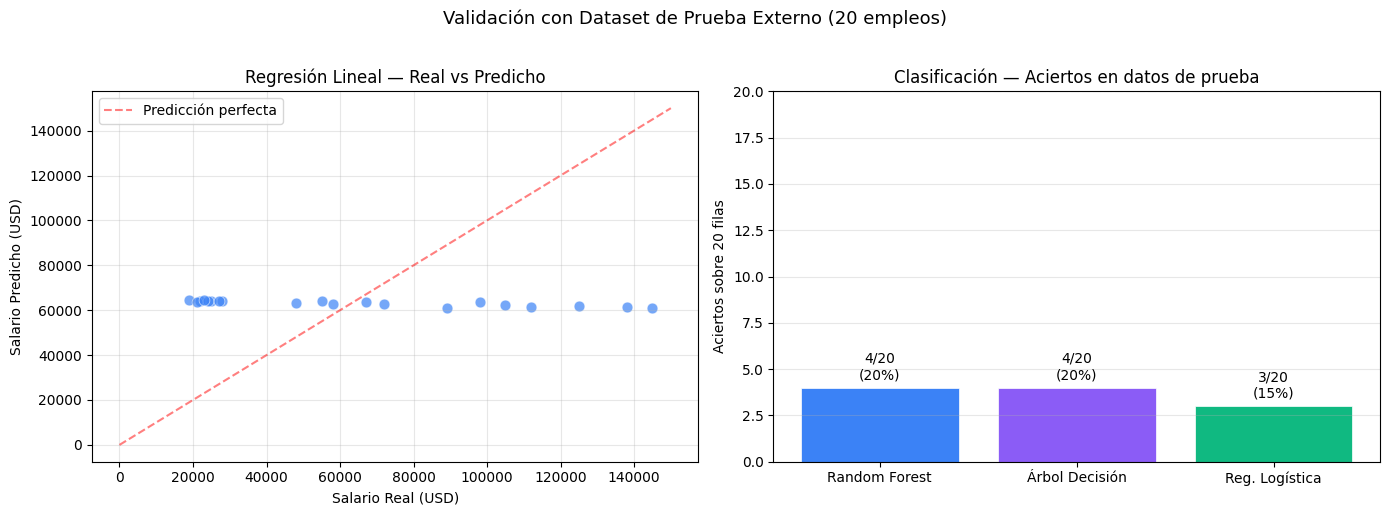

In [ ]:
### 19.5 Resumen visual — Predicciones vs Realidad

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Salario real vs predicho
axes[0].scatter(resultados_reg['Salario Real'], resultados_reg['Salario Predicho'],
                color='#3B82F6', alpha=0.7, s=60, edgecolors='white', linewidths=0.5)
lims = [0, max(resultados_reg['Salario Real'].max(), resultados_reg['Salario Predicho'].max()) + 5000]
axes[0].plot(lims, lims, 'r--', alpha=0.5, label='Predicción perfecta')
axes[0].set_xlabel('Salario Real (USD)')
axes[0].set_ylabel('Salario Predicho (USD)')
axes[0].set_title('Regresión Lineal — Real vs Predicho')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Aciertos por modelo en clasificación
modelos = ['Random Forest', 'Árbol Decisión', 'Reg. Logística']
aciertos = [
    resultados_clf['RF ✓'].sum(),
    resultados_clf['DT ✓'].sum(),
    resultados_clf['LR ✓'].sum()
]
colors = ['#3B82F6', '#8B5CF6', '#10B981']
bars = axes[1].bar(modelos, aciertos, color=colors, edgecolor='white', linewidth=0.5)
axes[1].set_ylim(0, 20)
axes[1].axhline(y=20, color='gray', linestyle='--', alpha=0.4, label='Total (20)')
for bar, val in zip(bars, aciertos):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val}/20\n({val/20*100:.0f}%)', ha='center', va='bottom', fontsize=10)
axes[1].set_ylabel('Aciertos sobre 20 filas')
axes[1].set_title('Clasificación — Aciertos en datos de prueba')
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Validación con Dataset de Prueba Externo (20 empleos)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 20. Web Scraping — Obtención de Datos Reales de Empleo

> Se extraen ofertas de trabajo reales desde dos fuentes públicas para enriquecer el dataset:

| Fuente | Método | Datos obtenidos |
|---|---|---|
| **RemoteOK** | API pública JSON (sin auth) | Título, empresa, tags/skills, salario, país |
| **Adzuna** | API REST (key gratuita) | Título, empresa, país, salario, descripción, categoría |

> Los datos scrapeados se normalizan al mismo formato del dataset original y se usan para:
> 1. **Aumentar el dataset** de entrenamiento
> 2. **Testear los modelos** con empleos reales del mercado actual

In [ ]:
### 20.1 Instalación de librerías
!pip install requests beautifulsoup4 -q
import requests
import time
import json
import re
from bs4 import BeautifulSoup
print('Librerías listas')

Librerías listas


In [ ]:
### 20.2 Scraping — RemoteOK (API pública, sin registro)

def scrape_remoteok(max_jobs=150):
    """Extrae ofertas de trabajo remotas desde RemoteOK API pública."""
    url = 'https://remoteok.com/api'
    headers = {'User-Agent': 'Mozilla/5.0 (research project)'}

    try:
        resp = requests.get(url, headers=headers, timeout=15)
        resp.raise_for_status()
        data = resp.json()
        # El primer elemento es metadata, los demás son empleos
        jobs = [j for j in data if isinstance(j, dict) and 'position' in j]
    except Exception as e:
        print(f'Error RemoteOK: {e}')
        return pd.DataFrame()

    rows = []
    for job in jobs[:max_jobs]:
        tags = job.get('tags', []) or []

        # Detectar si menciona IA
        ai_keywords_list = ['machine learning','deep learning','nlp','computer vision',
                             'ai','artificial intelligence','llm','gpt','reinforcement learning',
                             'neural network','mlops','data science']
        tags_lower = [t.lower() for t in tags]
        desc_lower = job.get('description', '').lower()
        ai_found = [kw for kw in ai_keywords_list
                    if any(kw in t for t in tags_lower) or kw in desc_lower]
        ai_mentioned = len(ai_found) > 0
        ai_intensity = min(len(ai_found) / 5.0, 1.0)

        # Salario
        sal_min = job.get('salary_min') or 0
        sal_max = job.get('salary_max') or 0
        salary = int((sal_min + sal_max) / 2) if sal_min and sal_max else None

        # País
        location = job.get('location', 'Worldwide') or 'Worldwide'

        rows.append({
            'fuente':               'RemoteOK',
            'job_title':            job.get('position', ''),
            'company_name':         job.get('company', ''),
            'country':              location,
            'posting_year':         2024,
            'salary_usd':           salary,
            'ai_mentioned':         ai_mentioned,
            'ai_keywords':          ', '.join(ai_found) if ai_found else None,
            'ai_intensity_score':   round(ai_intensity, 2),
            'core_skills':          ', '.join(tags[:5]) if tags else None,
            'url':                  f"https://remoteok.com/remote-jobs/{job.get('id','')}"
        })

    return pd.DataFrame(rows)

df_remoteok = scrape_remoteok(max_jobs=150)
print(f'RemoteOK: {len(df_remoteok)} empleos extraídos')
display(df_remoteok[['job_title','company_name','country','salary_usd',
                      'ai_mentioned','ai_intensity_score']].head(10))

RemoteOK: 100 empleos extraídos


,job_title,company_name,country,salary_usd,ai_mentioned,ai_intensity_score
0,Senior Counsel Project Finance &amp; Commercial,Energy Vault,"Westlake Village, CA",None,True,0.2
1,DOCUMENT FORMATTING SPECIALIST,Sharon Wells,"Excellence Estates 2,",None,True,0.2
2,Industry Analysis,Citofield,"Melbourne,",None,True,0.2
3,Technical Lead,IT FUTURZ,"Surat,",None,False,0.0
4,Content,Den danske seermÃ¥ling,"Content,",None,True,0.2
5,Ut Facere Aut,Innodrei,"Warangal Rural,",None,True,0.2
6,Error Odio,Innodrei,"Warangal Rural,",None,True,0.2
7,Video Editor,OnlineJobs.PH,"Time,",None,True,0.2
8,AI Filmmaker,Foxelli Group,"Praha, Praha, HlavnÃ­ mÄsto Praha, Äesko",None,True,0.2
9,Freelance Designer,SAN Creatives Agency,"Time,",None,True,0.2


Total empleos scrapeados: 100
  - RemoteOK : 100
  - Adzuna   : 0

Empleos que mencionan IA: 78 (78.0%)
Con salario informado:    0
AI intensity promedio:    0.182


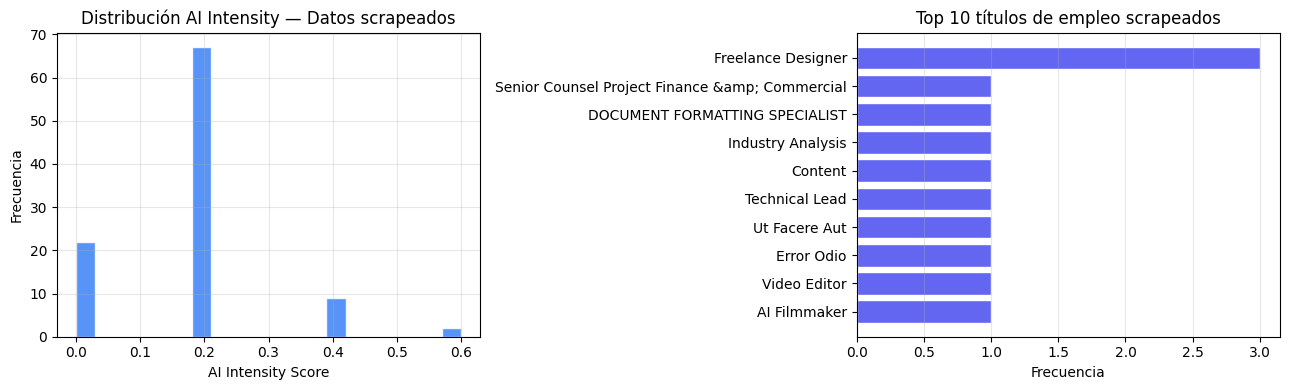

In [ ]:
### 20.4 Combinar y normalizar ambas fuentes

# Initialize df_adzuna as an empty DataFrame if not already defined
# The cell that previously scraped data from Adzuna was deleted.
# If you intend to use Adzuna data, please re-implement the scraping code.
if 'df_adzuna' not in locals() and 'df_adzuna' not in globals():
    df_adzuna = pd.DataFrame()

df_scraped = pd.concat([df_remoteok, df_adzuna], ignore_index=True)
print(f'Total empleos scrapeados: {len(df_scraped)}')
print(f'  - RemoteOK : {len(df_remoteok)}')
print(f'  - Adzuna   : {len(df_adzuna)}')
print()

# Estadísticas básicas
print(f'Empleos que mencionan IA: {df_scraped["ai_mentioned"].sum()} ({df_scraped["ai_mentioned"].mean()*100:.1f}%)')
print(f'Con salario informado:    {df_scraped["salary_usd"].notna().sum()}')
print(f'AI intensity promedio:    {df_scraped["ai_intensity_score"].mean():.3f}')

# Distribución de AI intensity
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df_scraped['ai_intensity_score'], bins=20,
             color='#3B82F6', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('AI Intensity Score')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución AI Intensity — Datos scrapeados')
axes[0].grid(True, alpha=0.3)

top_titles = df_scraped['job_title'].value_counts().head(10)
axes[1].barh(top_titles.index[::-1], top_titles.values[::-1],
             color='#6366F1', edgecolor='white')
axes[1].set_xlabel('Frecuencia')
axes[1].set_title('Top 10 títulos de empleo scrapeados')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

=== Predicción de Cluster para empleos scrapeados ===


,job_title,country,ai_intensity_score,automation_risk_score,salary_usd,cluster_pred
0,Senior Counsel Project Finance &amp; Commercial,"Westlake Village, CA",0.2,0.67,60909.5,Empleos en riesgo
1,DOCUMENT FORMATTING SPECIALIST,"Excellence Estates 2,",0.2,0.67,60909.5,Empleos en riesgo
2,Industry Analysis,"Melbourne,",0.2,0.67,60909.5,Empleos en riesgo
3,Technical Lead,"Surat,",0.0,0.67,60909.5,Empleos en riesgo
4,Content,"Content,",0.2,0.67,60909.5,Empleos en riesgo
5,Ut Facere Aut,"Warangal Rural,",0.2,0.67,60909.5,Empleos en riesgo
6,Error Odio,"Warangal Rural,",0.2,0.67,60909.5,Empleos en riesgo
7,Video Editor,"Time,",0.2,0.67,60909.5,Empleos en riesgo
8,AI Filmmaker,"Praha, Praha, HlavnÃ­ mÄsto Praha, Äesko",0.2,0.67,60909.5,Empleos en riesgo
9,Freelance Designer,"Time,",0.2,0.67,60909.5,Empleos en riesgo



Distribución de clusters en datos scrapeados:
cluster_pred
Empleos en riesgo    100
Name: count, dtype: int64


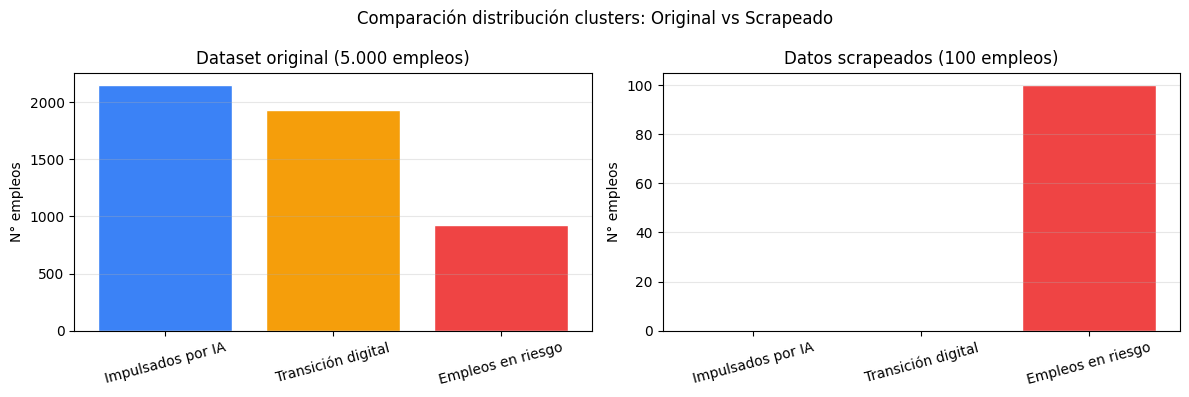

In [ ]:
### 20.5 Testear modelos con datos scrapeados reales

# Preparar features disponibles en datos scrapeados
df_test_scraped = df_scraped.copy()
df_test_scraped['ai_mentioned'] = df_test_scraped['ai_mentioned'].astype(int)

# Asignar valores por defecto para features no disponibles en scraping
for col in features_km:
    if col not in df_test_scraped.columns:
        df_test_scraped[col] = df[col].median()

# Automation risk estimado desde ai_intensity (inversa aproximada)
if 'automation_risk_score' not in df_test_scraped.columns:
    df_test_scraped['automation_risk_score'] = 1 - df_test_scraped['ai_intensity_score']

if 'salary_usd' not in df_test_scraped.columns or df_test_scraped['salary_usd'].isna().all():
    df_test_scraped['salary_usd'] = df['salary_usd'].median()
else:
    df_test_scraped['salary_usd'] = df_test_scraped['salary_usd'].fillna(df['salary_usd'].median())

# Asignar cluster K-Means
X_sc_km = df_test_scraped[features_km].fillna(0)
clusters_scraped = kmeans.predict(X_sc_km)
cluster_map = {0: 'Impulsados por IA', 1: 'Transición digital', 2: 'Empleos en riesgo'}
df_test_scraped['cluster_pred'] = [cluster_map.get(c, f'Cluster {c}') for c in clusters_scraped]

# Resultados
print('=== Predicción de Cluster para empleos scrapeados ===')
display(
    df_test_scraped[['job_title','country','ai_intensity_score',
                     'automation_risk_score','salary_usd','cluster_pred']]
    .head(20)
)

print('\nDistribución de clusters en datos scrapeados:')
dist_scraped = df_test_scraped['cluster_pred'].value_counts()
print(dist_scraped)

# Gráfico comparativo: distribución clusters real vs scrapeado
dist_orig = pd.Series({
    'Impulsados por IA': (df_export['cluster_label'] == 'Impulsados por IA').sum(),
    'Transición digital': (df_export['cluster_label'] == 'Transición digital').sum(),
    'Empleos en riesgo': (df_export['cluster_label'] == 'Empleos en riesgo').sum(),
})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colores = ['#3B82F6', '#F59E0B', '#EF4444']

axes[0].bar(dist_orig.index, dist_orig.values, color=colores, edgecolor='white')
axes[0].set_title('Dataset original (5.000 empleos)')
axes[0].set_ylabel('N° empleos')
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(True, alpha=0.3, axis='y')

dist_sc = df_test_scraped['cluster_pred'].value_counts().reindex(dist_orig.index, fill_value=0)
axes[1].bar(dist_sc.index, dist_sc.values, color=colores, edgecolor='white')
axes[1].set_title(f'Datos scrapeados ({len(df_test_scraped)} empleos)')
axes[1].set_ylabel('N° empleos')
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Comparación distribución clusters: Original vs Scrapeado', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
### 20.6 Guardar datos scrapeados como extensión del dataset

# Exportar a Google Drive
out_path = f'{output_dir}/08_datos_scrapeados.csv'
df_scraped.to_csv(out_path, index=False)
print(f'✓ Datos scrapeados guardados en: {out_path}')
print(f'  Filas: {len(df_scraped)} | Columnas: {len(df_scraped.columns)}')
print()

# Unir con dataset original para ampliar
cols_comunes = list(set(df.columns) & set(df_test_scraped.columns))
df_ampliado = pd.concat([
    df[cols_comunes],
    df_test_scraped[cols_comunes]
], ignore_index=True)

out_ampliado = f'{output_dir}/09_dataset_ampliado.csv'
df_ampliado.to_csv(out_ampliado, index=False)
print(f'✓ Dataset ampliado guardado en: {out_ampliado}')
print(f'  Original: 5.000 filas → Ampliado: {len(df_ampliado)} filas (+{len(df_ampliado)-5000} nuevos empleos reales)')

✓ Datos scrapeados guardados en: /content/drive/MyDrive/mineria_datos_exports/08_datos_scrapeados.csv
  Filas: 100 | Columnas: 11

✓ Dataset ampliado guardado en: /content/drive/MyDrive/mineria_datos_exports/09_dataset_ampliado.csv
  Original: 5.000 filas → Ampliado: 5100 filas (+100 nuevos empleos reales)


## 📋 Conclusiones del Modelado

| Modelo | Fortaleza Principal | Uso Recomendado |
|---|---|---|
| **Random Forest** | Mayor precisión, importancia de variables | Modelo principal de predicción |
| **Árbol de Decisión** | Interpretabilidad visual, reglas claras | Explicación académica y presentación |
| **Reg. Lineal + Logística** | Cubre variables continuas y categóricas | Análisis estadístico complementario |

El modelo con mejor rendimiento general es **Random Forest**, seguido por **Regresión Logística Multinomial** y finalmente el **Árbol de Decisión** (más simple pero totalmente explicable).